# Mini-projet n°1 – Chats ou Chiens ?

#### Téléchargement des librairies

In [1]:
import os
import shutil
import time

# Maths - Stats
from sklearn.utils import shuffle
import numpy as np
import pandas as pd
import random as rd

# Data visualization
from matplotlib import pyplot as plt
import seaborn as sns
from PIL import Image

# Deep Learning Librairies
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Flatten, Dropout,  GlobalAveragePooling2D
from tensorflow.keras.models import Sequential, clone_model, Model,load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16 


2026-01-19 17:30:55.026638: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-19 17:30:55.039570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768840255.053042   69564 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768840255.057181   69564 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768840255.067687   69564 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
[k.device_type for k in tf.config.list_physical_devices()]

['CPU', 'GPU']

## 1. Chargement des données

In [3]:
df = pd.read_csv(
    "./oxford-iiit-pet/annotations/list.txt",
    sep=r"\s+",                                         
    comment="#",                                        
    header=None,                                        
    names=["Image", "CLASS_ID", "SPECIES", "BREED_ID"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7349 entries, 0 to 7348
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Image     7349 non-null   object
 1   CLASS_ID  7349 non-null   int64 
 2   SPECIES   7349 non-null   int64 
 3   BREED_ID  7349 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 229.8+ KB


Le jeu de données est composé de 7349 individus.
Les variables sont les suivantes :
- Image : au format .jpg ;
- CLASS\_ID (race) : 37 races différentes ;
- SPECIES : chat ou chien (1 ou 2 selon l'espèce) ;
- BREED\_ID : identifiant de la race parmi l'espèce concernée.

Afin de rendre les données plus lisibles, nous rajoutons deux variables non numériques précisant les noms de l'espèce (SPECIES\_NAME) et de la race (BREED\_NAME) de chaque individu.

In [4]:
df["BREED_NAME"] = df["Image"].str.rsplit("_", n=1).str[0]           # Nom de la race
df["SPECIES_NAME"] = df["SPECIES"].map({1: "Cat", 2: "Dog"})         # Chat ou chien
df["Image"] = df["Image"].apply(lambda x: f"{x}.jpg")

print(df.sample(n=3, random_state=42))

                      Image  CLASS_ID  SPECIES  BREED_ID      BREED_NAME  \
2755       keeshond_164.jpg        19        2        13        keeshond   
2966   newfoundland_178.jpg        23        2        16    newfoundland   
5186  great_pyrenees_31.jpg        16        2        10  great_pyrenees   

     SPECIES_NAME  
2755          Dog  
2966          Dog  
5186          Dog  


#### Division du dataset

In [5]:
base_path = "./oxford-iiit-pet/"
img_dir = os.path.join(base_path, "images/")
mask_dir = os.path.join(base_path, "annotations/trimaps/")

df['mask_filename'] = df['Image'].str.replace('.jpg', '.png')

# --- Division du Dataset (Train / Val / Test) ---
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['SPECIES_NAME'])
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['SPECIES_NAME'])

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

Train: 4703 | Validation: 1176 | Test: 1470


## 2. Analyse des données

### A. Étude de la répartition par race et par type


SPECIES_NAME
Dog    4978
Cat    2371
Name: count, dtype: int64

Pourcentages:
SPECIES_NAME
Dog    67.737107
Cat    32.262893
Name: count, dtype: float64


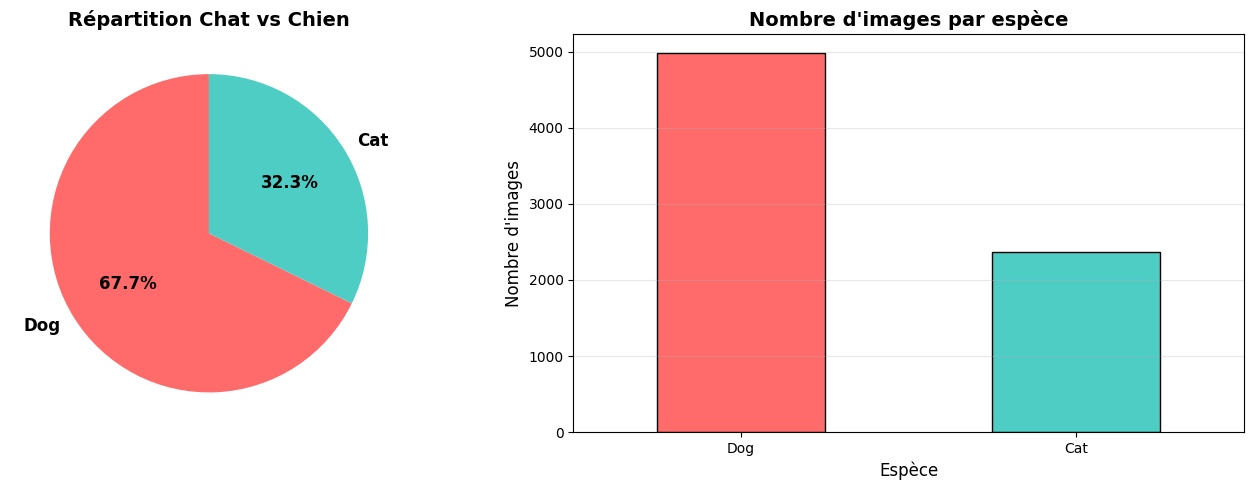

In [6]:
species_counts = df["SPECIES_NAME"].value_counts()
print(f"\n{species_counts}")
print(f"\nPourcentages:")
print(species_counts / len(df) * 100)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = ['#FF6B6B', '#4ECDC4']
axes[0].pie(species_counts, labels=species_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Répartition Chat vs Chien', fontsize=14, weight='bold')

# Bar chart
species_counts.plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Nombre d\'images par espèce', fontsize=14, weight='bold')
axes[1].set_xlabel('Espèce', fontsize=12)
axes[1].set_ylabel('Nombre d\'images', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

L'analyse de la répartition des données révèle un déséquilibre significatif entre les deux classes. La classe Dog est prédominante, représentant 67,7 % du jeu de données (environ 5 000 images), tandis que la classe Cat est minoritaire avec seulement 32,3 % (environ 2 400 images), soit un ratio approximatif de 2 pour 1 en faveur des chiens.


Nombre total de races: 37

Top 10 races les plus représentées:
BREED_NAME
american_bulldog             200
basset_hound                 200
american_pit_bull_terrier    200
beagle                       200
Bengal                       200
yorkshire_terrier            200
Birman                       200
chihuahua                    200
British_Shorthair            200
havanese                     200
Name: count, dtype: int64

Top 10 races les moins représentées:
BREED_NAME
Siamese                       199
boxer                         199
keeshond                      199
scottish_terrier              199
Abyssinian                    198
english_cocker_spaniel        196
newfoundland                  196
Egyptian_Mau                  190
staffordshire_bull_terrier    189
Bombay                        184
Name: count, dtype: int64
Statistiques:
Moyenne d'images par race: 198.62
Médiane: 200.00
Écart-type: 3.52
Min: 184 | Max: 200


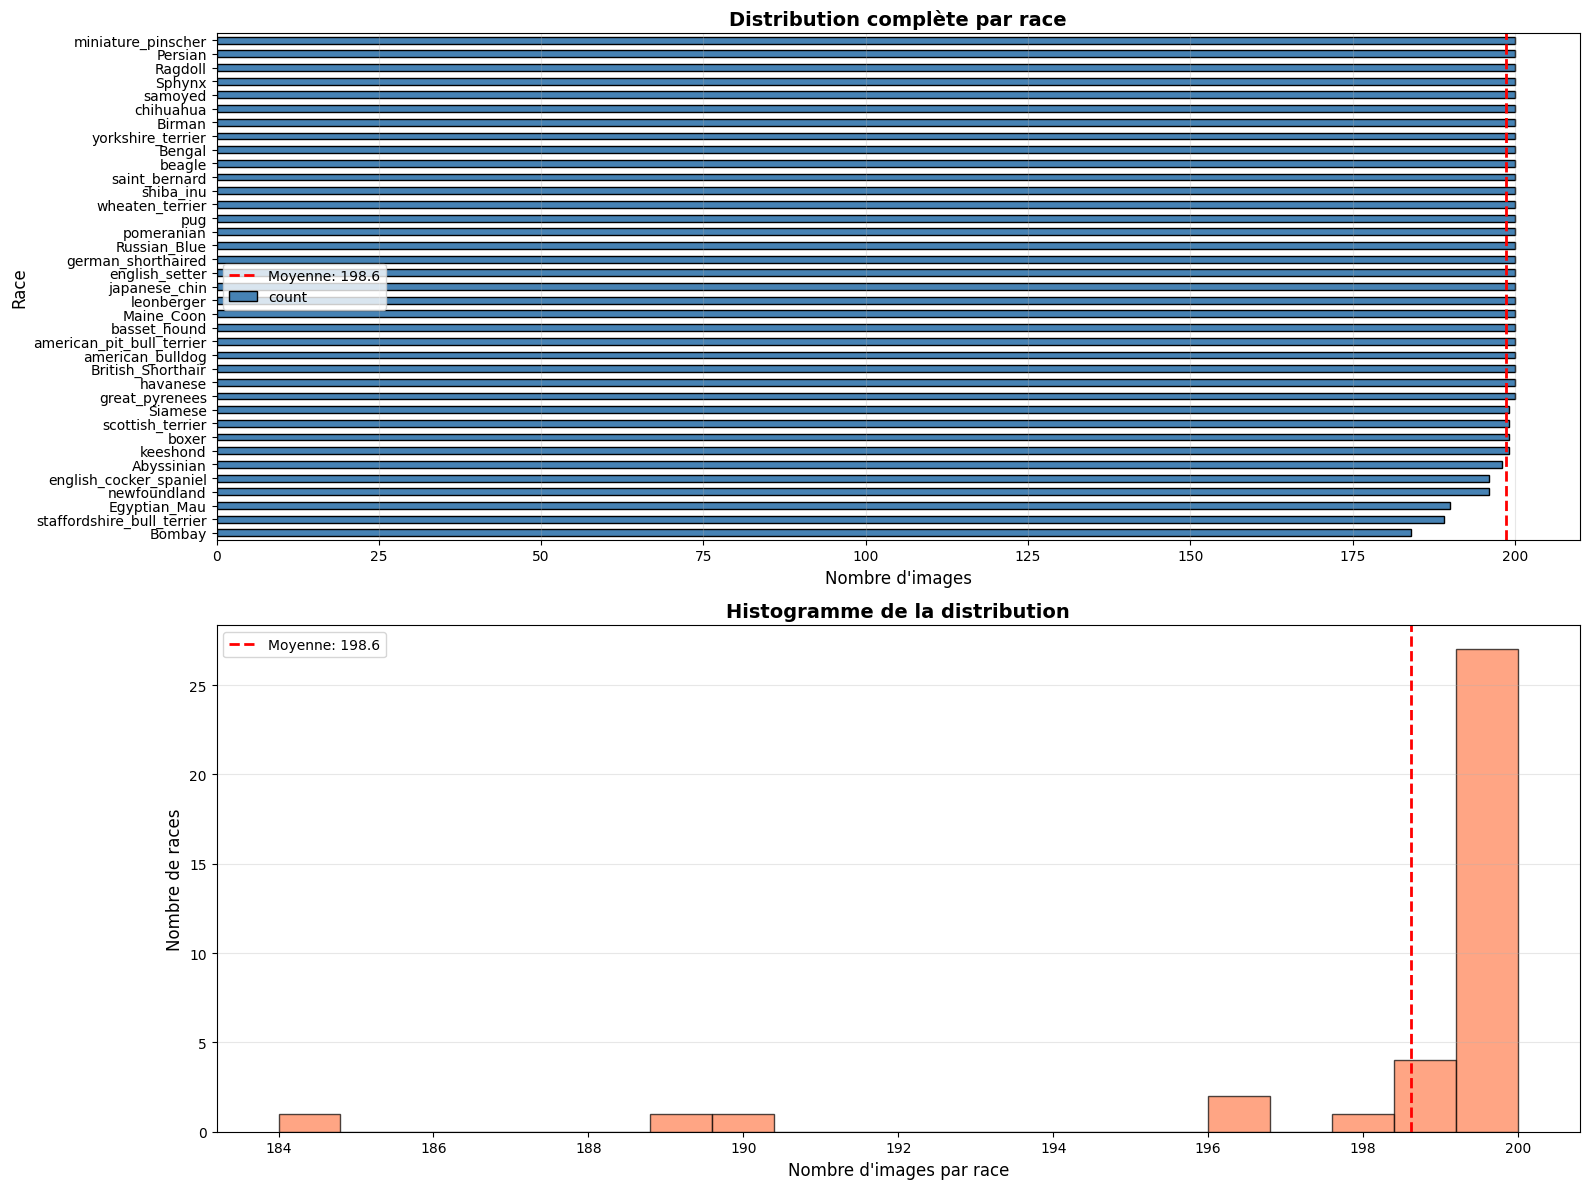

In [7]:
breed_counts = df["BREED_NAME"].value_counts().sort_values(ascending=False)
print(f"\nNombre total de races: {len(breed_counts)}")
print(f"\nTop 10 races les plus représentées:")
print(breed_counts.head(10))
print(f"\nTop 10 races les moins représentées:")
print(breed_counts.tail(10))

# Statistiques
print(f"Statistiques:")
print(f"Moyenne d'images par race: {breed_counts.mean():.2f}")
print(f"Médiane: {breed_counts.median():.2f}")
print(f"Écart-type: {breed_counts.std():.2f}")
print(f"Min: {breed_counts.min()} | Max: {breed_counts.max()}")

# Visualisation complète
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Toutes les races
breed_counts.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribution complète par race', fontsize=14, weight='bold')
axes[0].set_xlabel('Nombre d\'images', fontsize=12)
axes[0].set_ylabel('Race', fontsize=12)
axes[0].axvline(x=breed_counts.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Moyenne: {breed_counts.mean():.1f}')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Histogramme de la distribution
axes[1].hist(breed_counts, bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Histogramme de la distribution', fontsize=14, weight='bold')
axes[1].set_xlabel('Nombre d\'images par race', fontsize=12)
axes[1].set_ylabel('Nombre de races', fontsize=12)
axes[1].axvline(x=breed_counts.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Moyenne: {breed_counts.mean():.1f}')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### B. Etude de la répartition par race et par espèce


Nombre de races de chats: 12
Nombre de races de chiens: 25

Races de chats: ['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx']

Races de chiens: ['american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


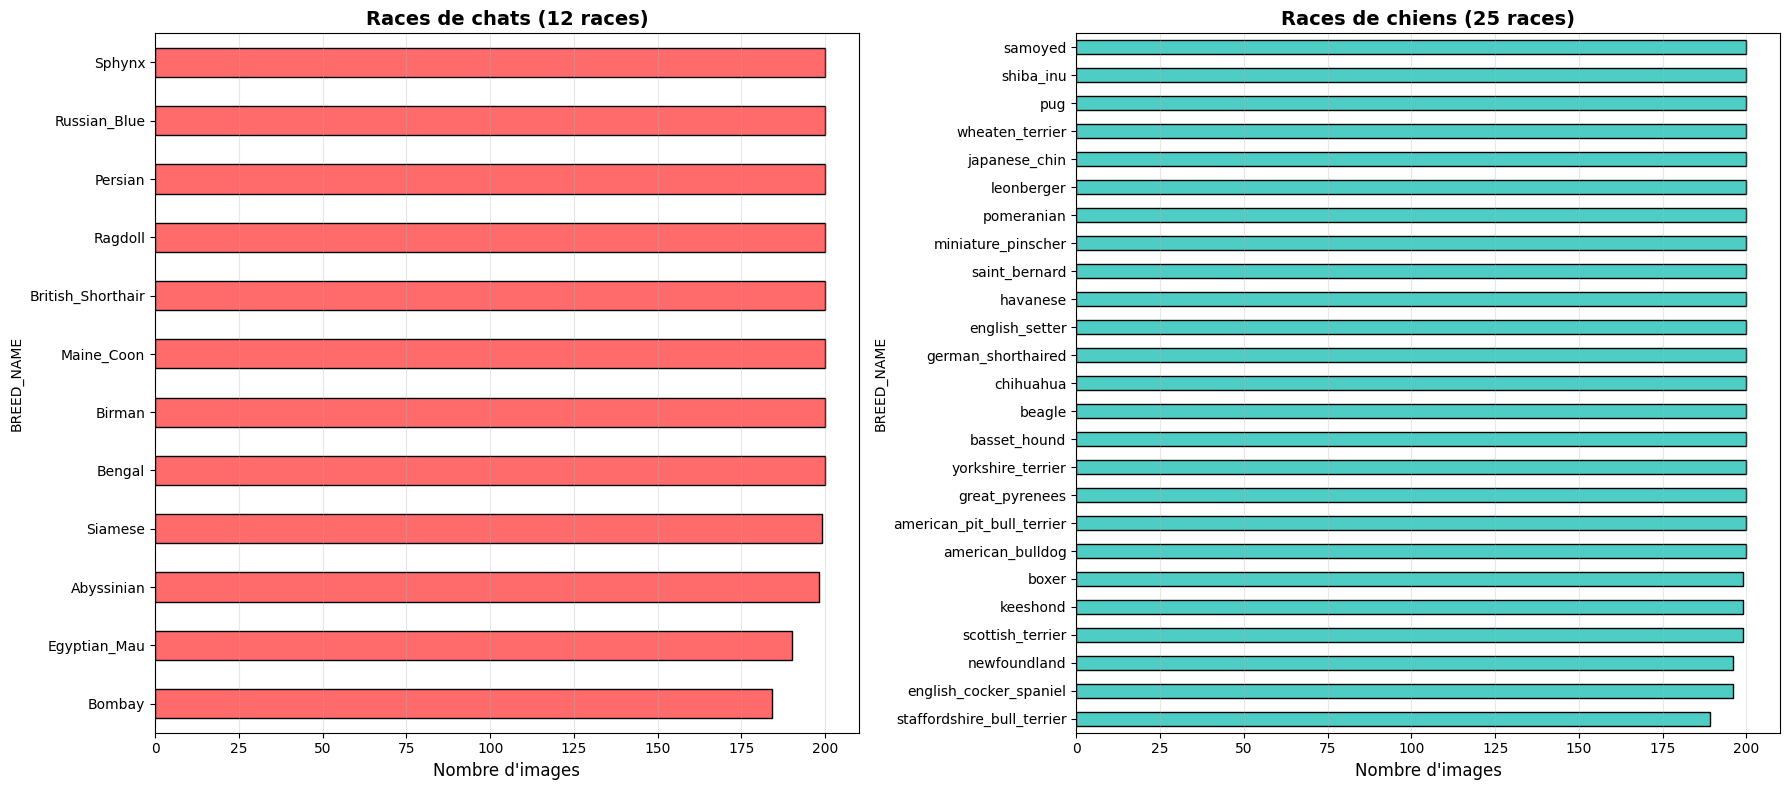

In [8]:
breed_species = df.groupby(['BREED_NAME', 'SPECIES_NAME']).size().reset_index(name='count')
cats_breeds = breed_species[breed_species['SPECIES_NAME'] == 'Cat']['BREED_NAME'].unique()
dogs_breeds = breed_species[breed_species['SPECIES_NAME'] == 'Dog']['BREED_NAME'].unique()

print(f"\nNombre de races de chats: {len(cats_breeds)}")
print(f"Nombre de races de chiens: {len(dogs_breeds)}")

print(f"\nRaces de chats: {sorted(cats_breeds)}")
print(f"\nRaces de chiens: {sorted(dogs_breeds)}")

# Visualisation séparée
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

cats_data = df[df['SPECIES_NAME'] == 'Cat']['BREED_NAME'].value_counts().sort_values()
dogs_data = df[df['SPECIES_NAME'] == 'Dog']['BREED_NAME'].value_counts().sort_values()

cats_data.plot(kind='barh', ax=axes[0], color='#FF6B6B', edgecolor='black')
axes[0].set_title(f'Races de chats ({len(cats_breeds)} races)', fontsize=14, weight='bold')
axes[0].set_xlabel('Nombre d\'images', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

dogs_data.plot(kind='barh', ax=axes[1], color='#4ECDC4', edgecolor='black')
axes[1].set_title(f'Races de chiens ({len(dogs_breeds)} races)', fontsize=14, weight='bold')
axes[1].set_xlabel('Nombre d\'images', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


Le nombre d'individus est environ le même pour chaque race (200). Les données semblent a priori équilibrées,  même si certaines races (Bombay, chat) n'ont pas autant d'individus que les autres.
On peut conclure cette sous-partie en avançant que les données sont suffisament bien réparties selon les espèces et les races. Il y a une légère sur-représentations des chiens, et les races sont légèrement déséquilibrés, mais cela ne devrait pas être impactant pour la suite.

### C. Cohérence des masques de segmentation

Chaque image possède trois masques de segmentation: foreground (le corps de l'animal), background (le fond de l'image) et not classified (qui correspond à la zone d'incertitude/la bordure).


Vérification en cours...
 Résultats (sur 100 images):
 Images présentes: 100/100 (100.0%)
 Masques présents: 100/100 (100.0%)
 Dimensions concordantes: 100/100 (100.0%)
 Masques valides (valeurs 1,2,3): 100/100 (100.0%)
  Visualisation d'exemples...
Visualisation des exemples terminée


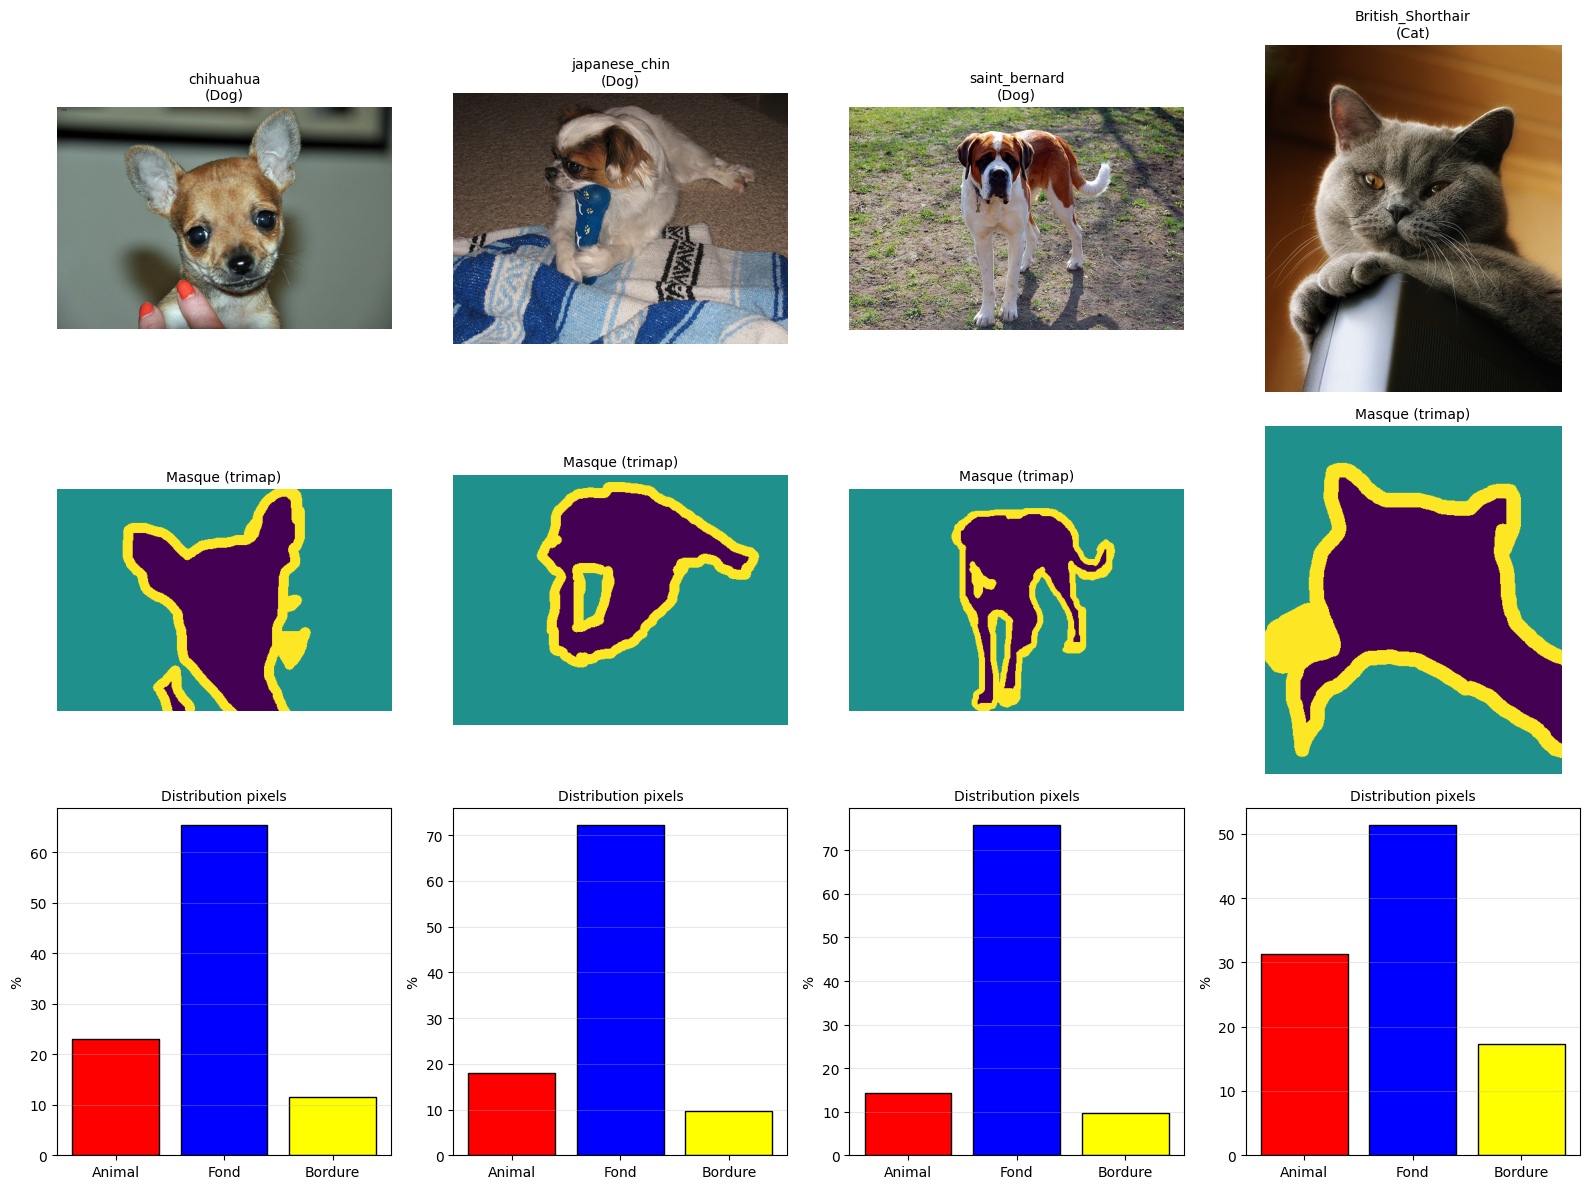

In [ ]:
images_dir = "./oxford-iiit-pet/images"
masks_dir = "./oxford-iiit-pet/annotations/trimaps"

# Vérifier l'existence des fichiers
images_exist = []
masks_exist = []
dimensions_match = []
mask_quality = []

print("\nVérification en cours...")
sample_size = min(100, len(df))  # Échantillon pour test rapide

for idx, row in df.head(sample_size).iterrows():
    img_name = row['Image']
    mask_name = img_name.replace('.jpg', '.png')
    
    img_path = os.path.join(images_dir, img_name)
    mask_path = os.path.join(masks_dir, mask_name)
    
    img_exists = os.path.exists(img_path)
    mask_exists = os.path.exists(mask_path)
    
    images_exist.append(img_exists)
    masks_exist.append(mask_exists)
    
    if img_exists and mask_exists:
        img = Image.open(img_path)
        mask = Image.open(mask_path)
        dimensions_match.append(img.size == mask.size)
        
        # Vérifier valeurs du masque
        mask_array = np.array(mask)
        unique_vals = np.unique(mask_array)
        valid_mask = all(val in [1, 2, 3] for val in unique_vals)
        mask_quality.append(valid_mask)
    else:
        dimensions_match.append(False)
        mask_quality.append(False)

print(f" Résultats (sur {sample_size} images):")
print(f" Images présentes: {sum(images_exist)}/{sample_size} ({sum(images_exist)/sample_size*100:.1f}%)")
print(f" Masques présents: {sum(masks_exist)}/{sample_size} ({sum(masks_exist)/sample_size*100:.1f}%)")
print(f" Dimensions concordantes: {sum(dimensions_match)}/{sample_size} ({sum(dimensions_match)/sample_size*100:.1f}%)")
print(f" Masques valides (valeurs 1,2,3): {sum(mask_quality)}/{sample_size} ({sum(mask_quality)/sample_size*100:.1f}%)")

# Visualiser des exemples
print("  Visualisation d'exemples...")
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

sample_indices = rd.sample(range(len(df)), 4)

for i, idx in enumerate(sample_indices):
    row = df.iloc[idx]
    img_name = row['Image']
    mask_name = img_name.replace('.jpg', '.png')
    
    img_path = os.path.join(images_dir, img_name)
    mask_path = os.path.join(masks_dir, mask_name)
    
    if os.path.exists(img_path) and os.path.exists(mask_path):
        # Image originale
        img = Image.open(img_path)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"{row['BREED_NAME']}\n({row['SPECIES_NAME']})", fontsize=10)
        axes[0, i].axis('off')
        
        # Masque
        mask = np.array(Image.open(mask_path))
        axes[1, i].imshow(mask, cmap='viridis')
        axes[1, i].set_title('Masque (trimap)', fontsize=10)
        axes[1, i].axis('off')
        
        # Statistiques du masque
        unique, counts = np.unique(mask, return_counts=True)
        props = counts / mask.size * 100
        axes[2, i].bar(['Animal', 'Fond', 'Bordure'], props, 
                      color=['red', 'blue', 'yellow'], edgecolor='black')
        axes[2, i].set_ylabel('%')
        axes[2, i].set_title('Distribution pixels', fontsize=10)
        axes[2, i].grid(axis='y', alpha=0.3)

plt.tight_layout()
print("Visualisation des exemples terminée")
plt.show()

En regardant les images, on a vu que la zone d'incertitude était parfois assez importante, surtout sur les photos sombres. On a eu peur que cela gêne le modèle. On a donc calculé pour chaque image la part de "flou" par rapport à la taille de l'animal. Le but était de vérifier si cette incertitude était acceptable ou trop grande pour entraîner notre réseau correctement.

Calcul des statistiques de pertinence...


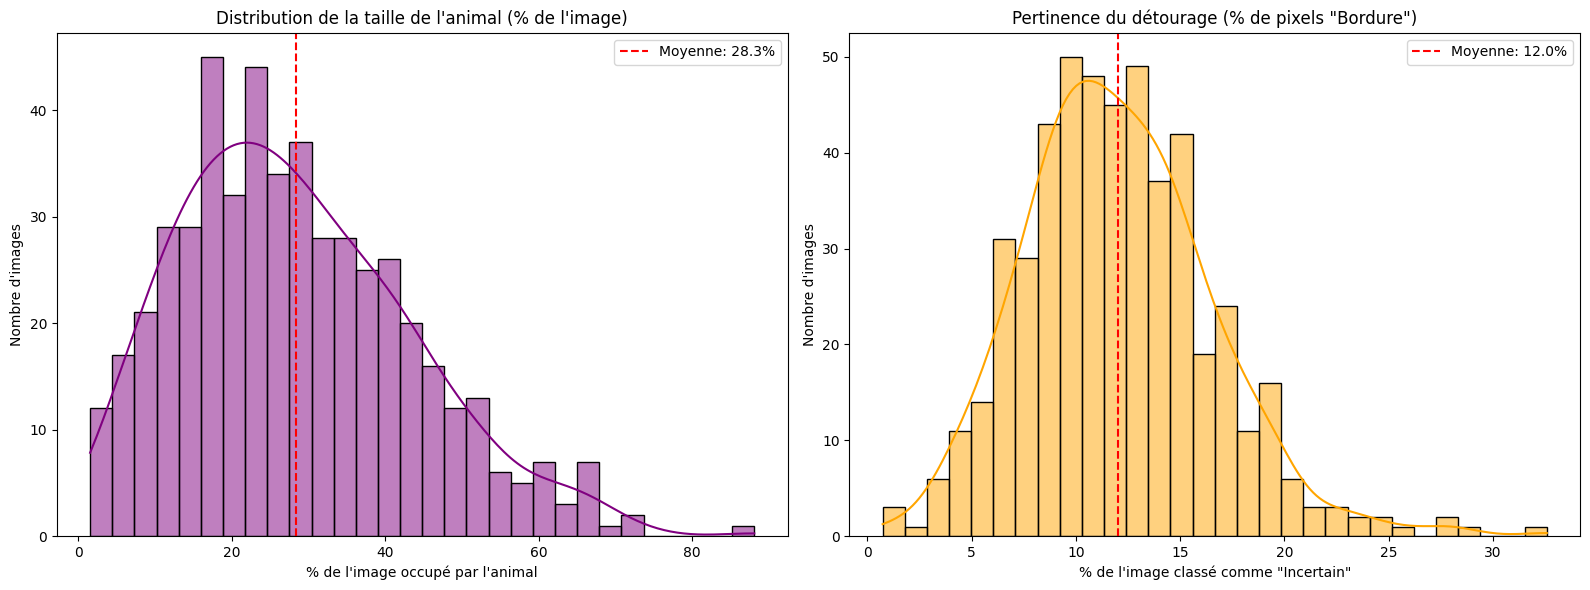

--- Conclusions ---
Moyenne de couverture de l'animal : 28.35%
Moyenne de la zone d'incertitude : 12.01%


In [ ]:

# Listes pour stocker les stats
stats_data = []

print("Calcul des statistiques de pertinence...")

# On parcourt un échantillon
for idx, row in df.head(500).iterrows():
    mask_path = os.path.join(masks_dir, row['Image'].replace('.jpg', '.png'))
    
    if os.path.exists(mask_path):
        try:
            mask = np.array(Image.open(mask_path))
            total_pixels = mask.size
            
            # Calcul des proportions
            animal_pct = np.sum(mask == 1) / total_pixels * 100
            background_pct = np.sum(mask == 2) / total_pixels * 100
            border_pct = np.sum(mask == 3) / total_pixels * 100
            
            stats_data.append({
                'Animal': animal_pct,
                'Fond': background_pct,
                'Bordure (Incertitude)': border_pct
            })
        except:
            continue


df_stats = pd.DataFrame(stats_data)

# --- VISUALISATION ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Analyse de la taille de l'animal (Densité d'info)
sns.histplot(df_stats['Animal'], bins=30, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution de la taille de l\'animal (% de l\'image)')
axes[0].set_xlabel('% de l\'image occupé par l\'animal')
axes[0].set_ylabel('Nombre d\'images')
axes[0].axvline(df_stats['Animal'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_stats["Animal"].mean():.1f}%')
axes[0].legend()

# 2. Analyse de la qualité du détourage (Bordure)
sns.histplot(df_stats['Bordure (Incertitude)'], bins=30, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Pertinence du détourage (% de pixels "Bordure")')
axes[1].set_xlabel('% de l\'image classé comme "Incertain"')
axes[1].set_ylabel('Nombre d\'images')
axes[1].axvline(df_stats['Bordure (Incertitude)'].mean(), color='red', linestyle='--', label=f'Moyenne: {df_stats["Bordure (Incertitude)"].mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

print("--- Conclusions ---")
print(f"Moyenne de couverture de l'animal : {df_stats['Animal'].mean():.2f}%")
print(f"Moyenne de la zone d'incertitude : {df_stats['Bordure (Incertitude)'].mean():.2f}%")

L'analyse statistique révèle d'abord que les données sont structurellement saines. Les sujets sont idéalement cadrés, l'animal occupe en moyenne 28,3 % de l'espace visuel. C'est un ratio optimal qui garantit que le modèle disposera de suffisamment de pixels pour identifier les textures de l'animal, tout en conservant assez de contexte pour comprendre l'arrière-plan.

Cependant, cette qualité est contrebalancée par un défaut majeur : la présence d'une large zone d'incertitude. Les bordures jaunes des trimaps représentent en moyenne 12 % des pixels de l'image, et cette proportion grimpe jusqu'à 30 % sur les clichés les plus complexes. Cela indique que la vérité terrain n'est pas nette : les annotateurs n'ayant pas pu détourer chaque poil, ils ont créé une marge d'erreur épaisse que le modèle ne pourra pas surpasser.

Cette contrainte impose d'ajuster nos attentes et notre méthode. Il faut accepter qu'une précision parfaite au pixel près est inatteignable, car le modèle apprendra inévitablement le flou inhérent aux données. Un score de précision qui plafonne autour de 90 % ne sera donc pas un signe d'échec, mais la limite théorique de ce dataset.

Concrètement, nous devrons adapter la fonction de perte (Loss) pour ne pas pénaliser le modèle lorsqu'il hésite dans cette zone floue.  Enfin, pour valider nos résultats, nous ne devrons pas nous fier à l'accuracy globale (souvent biaisée par le fond), mais surveiller le score IoU (Intersection over Union) spécifique à la classe « Animal », qui sera le seul véritable indicateur de performance.

## 3. Classification binaire

### A. Pre processing

In [11]:
batch_size = 20  # doit être un diviseur de N_train and N_validation (20 est bien un diviseur de 5200 et 1000, c'est pour ça qu'on a pris des valeurs rondes pour N_train et N_validation)
img_width = 150
img_height = 150

# Training images
train_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    img_dir,
    x_col = 'Image',
    y_col = 'SPECIES_NAME',
    target_size = (img_width, img_height),
    class_mode = 'binary',
    batch_size = batch_size,
    shuffle= True
)

# Validation images
val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_dataframe(
    val_df,
    img_dir,
    x_col = 'Image',
    y_col = 'SPECIES_NAME',
    class_mode = 'binary',
    target_size = (img_width, img_height),
    batch_size = batch_size,
    shuffle= False,
)

# Test images
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    img_dir,
    x_col = 'Image',
    y_col = 'SPECIES_NAME',
    class_mode = 'binary',
    target_size = (img_width, img_height),
    batch_size = batch_size,
    shuffle=False)

Found 4703 validated image filenames belonging to 2 classes.
Found 1176 validated image filenames belonging to 2 classes.
Found 1470 validated image filenames belonging to 2 classes.


Ce code configure le pipeline de préparation des données pour la classification binaire (Chats vs Chiens). Il définit d'abord les hyperparamètres structurels, fixant la résolution des images à 150×150 pixels et la taille des lots (batch_size) à 20, une valeur choisie pour diviser exactement le nombre total d'échantillons. Trois instances d'ImageDataGenerator sont ensuite créées pour les ensembles d'entraînement, de validation et de test, appliquant uniquement une normalisation des pixels (rescale=1./255) pour ramener leurs valeurs dans l'intervalle [0,1]. La méthode flow_from_dataframe est utilisée pour générer les flux de données en associant les fichiers images du répertoire img_dir (colonne 'Image') à leurs étiquettes cibles (colonne 'SPECIES_NAME'). Enfin, le paramètre class_mode='binary' est spécifié pour encoder les étiquettes en format binaire, adaptant ainsi les données à une sortie à deux classes.

### B. CNN

In [12]:
def cnn_simple(nom):
    # Initialisation du modèle Séquentiel (les couches s'empilent les unes après les autres)
    cnn = Sequential(name=nom)
    cnn.add(Input(shape=(img_width,img_height,3)))

    cnn.add(Conv2D(32, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(64, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(96, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    #cnn_simple.add(Conv2D(128, (3,3), activation='relu'))
    #cnn_simple.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Flatten())
    # cnn_simple.add(Dense(512, activation='relu'))
    cnn.add(Dense(64, activation='relu'))
    #cnn_simple.add(Dropout(0.5))
    cnn.add(Dense(1, activation='sigmoid'))

    
    return cnn

Ce réseau fonctionne en deux phases distinctes. D'abord, la phase d'extraction (les blocs Conv2D + MaxPooling) agit comme un entonnoir : elle réduit progressivement la taille de l'image (hauteur/largeur) tout en augmentant la profondeur (le nombre de filtres passe de 32 à 96). Cela permet au modèle de détecter d'abord des détails simples (bords, textures) avec peu de filtres, puis de combiner ces informations pour reconnaître des formes complexes (oreilles, museaux) avec plus de filtres. Ensuite, la phase de décision (Flatten + Dense) « aplatit » cette riche information en un vecteur unique pour qu'un petit réseau de neurones classique puisse prendre la décision finale (0 ou 1). C'est un compromis léger et efficace pour des tâches où un modèle massif comme VGG serait trop lourd.

In [13]:
cnn_naif=cnn_simple("cnn_simple")
cnn_naif.summary()        

I0000 00:00:1768840276.454570   69564 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13470 MB memory:  -> device: 0, name: NVIDIA RTX 2000 Ada Generation, pci bus id: 0000:55:00.0, compute capability: 8.9


Model: "cnn_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 27744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,775,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,850,529 (7.06 MB)

 Trainable params: 1,850,529 (7.06 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def Entrainement(cnn,train_generator, epochs=10, learn_rate = 3e-4):
    print("Entrainement de ",cnn.name)
    cnn.compile(
        loss = 'binary_crossentropy',
        optimizer = Adam(learning_rate=learn_rate),
        metrics = ['accuracy'])

    t_learning_cnn = time.time()
    
    cnn_history = cnn.fit(
        train_generator,
        validation_data = val_generator,
        epochs = epochs
    )
    
    t_learning_cnn = time.time() - t_learning_cnn
    print("Learning time for %d epochs : %d seconds" % (epochs, t_learning_cnn))
    
    return t_learning_cnn, cnn_history

La Binary Cross-Entropy est la fonction de "punition" mathématique utilisée spécifiquement pour les questions à réponse oui/non (classification binaire). Elle mesure la distance entre la probabilité prédite par le modèle (une valeur entre 0 et 1 issue de la sigmoid) et la vraie étiquette (qui est soit strictement 0, soit strictement 1). Son fonctionnement est logarithmique : si le modèle prédit 0.9 alors que c'est un chien (1), la punition est faible ; mais si le modèle prédit avec confiance 0.1 (c'est un chat) alors que c'est un chien, la punition explose. Elle force donc le modèle non seulement à avoir raison, mais à être confiant dans ses prédictions, en le pénalisant très sévèrement pour ses erreurs flagrantes.

In [15]:
t_learning_cnn_naif, cnn_naif_history = Entrainement(cnn_naif,train_generator)

Entrainement de  cnn_simple


/home/j_lauren/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1768840278.964236   69764 service.cc:152] XLA service 0x72dec4004dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768840278.964270   69764 service.cc:160]   StreamExecutor device (0): NVIDIA RTX 2000 Ada Generation, Compute Capability 8.9
2026-01-19 17:31:18.989586: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768840279.263793   69764 cuda_dnn.cc:529] Loaded cuDNN version 91701


  1/236 ━━━━━━━━━━━━━━━━━━━━ 13:30 3s/step - accuracy: 0.3000 - loss: 0.7201

I0000 00:00:1768840281.249937   69764 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


236/236 ━━━━━━━━━━━━━━━━━━━━ 104s 429ms/step - accuracy: 0.6631 - loss: 0.6193 - val_accuracy: 0.7168 - val_loss: 0.5266
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 25s 104ms/step - accuracy: 0.7209 - loss: 0.5431 - val_accuracy: 0.7670 - val_loss: 0.5110
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.7697 - loss: 0.4765 - val_accuracy: 0.7951 - val_loss: 0.4575
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.7982 - loss: 0.4327 - val_accuracy: 0.7832 - val_loss: 0.4417
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - accuracy: 0.8353 - loss: 0.3769 - val_accuracy: 0.7772 - val_loss: 0.4695
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - accuracy: 0.8647 - loss: 0.3294 - val_accuracy: 0.8019 - val_loss: 0.4290
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 78ms/step - accuracy: 0.8894 - loss: 0.2664 - val_accuracy: 0.7934 - val_loss: 0.4732
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 75ms/step - accuracy: 0.9143 - loss: 0.2202 - val_accu

In [16]:

def plot_training_analysis(history):
    
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', linestyle="--",label='Training accuracy')
    plt.plot(epochs, val_acc, 'g', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', linestyle="--",label='Training loss')
    plt.plot(epochs, val_loss,'g', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

def Analyse_resultats(cnn,cnn_history):
    t_prediction_cnn = time.time()
    score_cnn_train = cnn.evaluate(train_generator, verbose=1)
    score_cnn_validation = cnn.evaluate(val_generator, verbose=1)

    t_prediction_cnn = time.time() - t_prediction_cnn

    print('Train accuracy:', score_cnn_train[1])
    print('Validation accuracy:', score_cnn_validation[1])
    print("Time Prediction: %.2f seconds" % t_prediction_cnn)

    plot_training_analysis(cnn_history)
    return t_prediction_cnn

236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9779 - loss: 0.0792
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.7768 - loss: 0.6533
Train accuracy: 0.9774612188339233
Validation accuracy: 0.7806122303009033
Time Prediction: 18.19 seconds


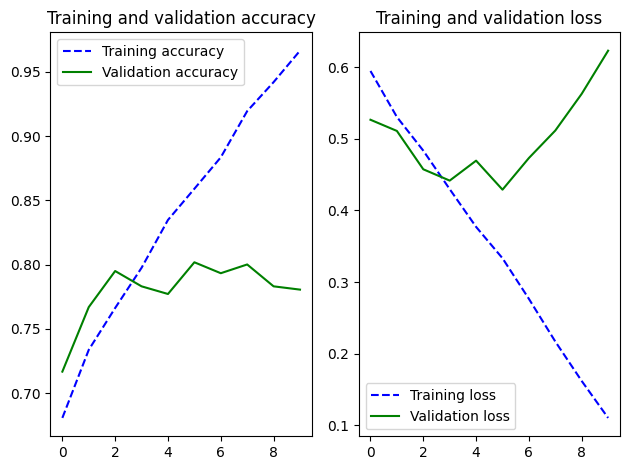

In [17]:
t_prediction_cnn_naif = Analyse_resultats(cnn_naif,cnn_naif_history)

train loss << val_loss  ==> overfitting ==> On va donc faire du dropout.


#### Drop-Out

In [18]:
def cnn_simple(nom):
    # Initialisation du modèle Séquentiel (les couches s'empilent les unes après les autres)
    cnn = Sequential(name=nom)
    cnn.add(Input(shape=(img_width,img_height,3)))

    cnn.add(Conv2D(32, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(64, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(96, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    #cnn_simple.add(Conv2D(128, (3,3), activation='relu'))
    #cnn_simple.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Flatten())
    # cnn_simple.add(Dense(512, activation='relu'))
    cnn.add(Dense(64, activation='relu'))
    cnn.add(Dropout(0.5))
    cnn.add(Dense(1, activation='sigmoid'))

    
    return cnn

In [19]:
cnn_naif_dropout=cnn_simple("cnn_simple_dropout")
cnn_naif_dropout.summary() 

Model: "cnn_simple_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 27744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,775,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,850,529 (7.06 MB)

 Trainable params: 1,850,529 (7.06 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
t_learning_cnn_naif_dropout, cnn_naif_dropout_history = Entrainement(cnn_naif_dropout,train_generator)

Entrainement de  cnn_simple_dropout
Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.6720 - loss: 0.6220 - val_accuracy: 0.7253 - val_loss: 0.5954
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.7041 - loss: 0.5704 - val_accuracy: 0.7245 - val_loss: 0.5160
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.7381 - loss: 0.5094 - val_accuracy: 0.7415 - val_loss: 0.5008
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.7368 - loss: 0.5161 - val_accuracy: 0.7849 - val_loss: 0.4846
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.7817 - loss: 0.4480 - val_accuracy: 0.7908 - val_loss: 0.4838
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.7935 - loss: 0.4339 - val_accuracy: 0.8129 - val_loss: 0.4339
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - accuracy: 0.8215 - loss: 0.3881 - val_accuracy: 0.8129 - val_loss: 0.4376
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step 

236/236 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.9168 - loss: 0.2241
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7977 - loss: 0.4447
Train accuracy: 0.9202636480331421
Validation accuracy: 0.8086734414100647
Time Prediction: 18.67 seconds


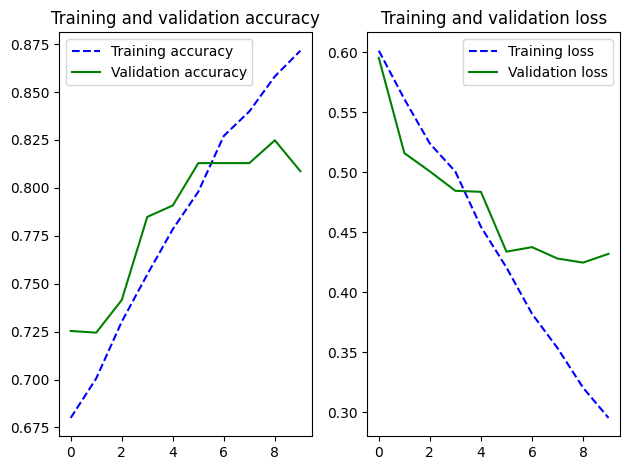

In [21]:
t_prediction_cnn_naif_dropout = Analyse_resultats(cnn_naif_dropout,cnn_naif_dropout_history)

Pour la suite, nous allons faire de la data augmentation afin d'améliorer les performances de notre modèle et de limiter le sur apprentissage.

#### Data augmentation

Définition : Technique consistant à créer des variantes artificielles des données d'entraînement (rotations, zooms, modifications de luminosité, etc.).

Objectif principal : Lutter contre le surapprentissage (overfitting) en augmentant artificiellement la taille du jeu de données.

Bénéfice : Améliore la robustesse et la capacité de généralisation du modèle en lui apprenant à ignorer les variations non pertinentes (ex: l'orientation d'un objet).

Application : Essentielle lorsque les données réelles sont limitées ou coûteuses à obtenir.

In [22]:
# Générateur avec Augmentation (Rotation, Zoom, Flip...)
aug_datagen = ImageDataGenerator(
    rotation_range = 10,
    rescale = 1./255,
    width_shift_range = 0.05,
    height_shift_range = 0.05,
    shear_range = 0.1,
    zoom_range = 0.1,
    brightness_range=[0.9,1.1], 
    channel_shift_range=10, 
    horizontal_flip = True,
    fill_mode='nearest'
)

# Seul le train est augmenté ! Val et Test restent "normaux"
train_gen_aug = aug_datagen.flow_from_dataframe(
    train_df, directory=img_dir, x_col='Image', y_col='SPECIES_NAME',
   target_size=(img_width, img_height), batch_size=batch_size, class_mode='binary' 
)

# On réutilise le même modèle, mais entraîné sur des données augmentées
cnn_aug = cnn_simple("cnn_augmente")
temps_aug,history_aug = Entrainement(
    cnn_aug, 
    train_gen_aug,  
    epochs=30,  
    learn_rate=3e-4
)



Found 4703 validated image filenames belonging to 2 classes.
Entrainement de  cnn_augmente


/home/j_lauren/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 121ms/step - accuracy: 0.6598 - loss: 0.6377 - val_accuracy: 0.6777 - val_loss: 0.5911
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 27s 113ms/step - accuracy: 0.6782 - loss: 0.5941 - val_accuracy: 0.6913 - val_loss: 0.5382
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - accuracy: 0.6949 - loss: 0.5653 - val_accuracy: 0.7245 - val_loss: 0.5233
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.7104 - loss: 0.5487 - val_accuracy: 0.7670 - val_loss: 0.4787
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - accuracy: 0.7393 - loss: 0.5244 - val_accuracy: 0.7313 - val_loss: 0.5048
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 28s 118ms/step - accuracy: 0.7470 - loss: 0.5097 - val_accuracy: 0.8010 - val_loss: 0.4597
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 32s 135ms/step - accuracy: 0.7716 - loss: 0.4889 - val_accuracy: 0.8002 - val_loss: 0.4404
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - accuracy: 0.7839 - loss: 0

236/236 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9131 - loss: 0.2304
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.8516 - loss: 0.3266
Train accuracy: 0.9126089811325073
Validation accuracy: 0.8613945841789246
Time Prediction: 16.38 seconds


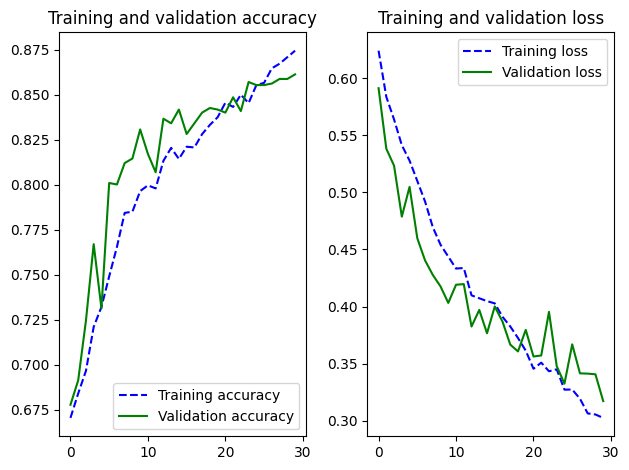

In [23]:
temps_prediction = Analyse_resultats(cnn_aug, history_aug)



Conclusion sur les premiers résultats et transition vers le Transfer Learning

Malgré la mise en place de stratégies de régularisation rigoureuses qui nous ont permi de limiter l'overfitting, notamment via la Data Augmentation (pour diversifier mon jeu de données) et l'ajout de couches Dropout (pour forcer le réseau à la robustesse), les performances de notre modèle restent insuffisantes. La loss stagne à un niveau trop élevé, ce qui indique que le problème ne vient plus uniquement du surapprentissage, mais probablement de la capacité limitée de l'architecture actuelle à extraire des caractéristiques pertinentes.

C'est pourquoi nous décidons de nous tourner vers une approche par Transfer Learning en utilisant le modèle pré-entraîné VGG16 pour les raisons suivantes :

- Au lieu de laisser notre modèle apprendre péniblement à reconnaître des formes basiques (bords, textures, contrastes), on utilise les poids optimisés de VGG16 sur ImageNet. Cela permet de bénéficier d'extracteurs de caractéristiques extrêmement performants dès le premier tour d'entraînement.

- Résolution du problème de convergence : VGG16, grâce à son architecture profonde et ses filtres déjà formés, offre un point de départ bien plus proche de la solution optimale, ce qui devrait mécaniquement faire chuter la loss.

- Optimisation de la capacité d'apprentissage : Tandis que nos efforts précédents (Dropout/Augmentation) visaient à limiter la mémorisation, l'utilisation de VGG16 vise à augmenter la qualité de la compréhension visuelle.



### C. Pre-trained Network : Utilisation de VGG 16

In [24]:
def plot_training_analysis(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', linestyle="--",label='Training accuracy')
    plt.plot(epochs, val_acc, 'g', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', linestyle="--",label='Training loss')
    plt.plot(epochs, val_loss,'g', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 37s 137ms/step - accuracy: 0.8190 - loss: 0.4102 - val_accuracy: 0.8954 - val_loss: 0.2299
Epoch 2/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.8827 - loss: 0.2661 - val_accuracy: 0.8963 - val_loss: 0.2366
Epoch 3/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 27s 114ms/step - accuracy: 0.9050 - loss: 0.2242 - val_accuracy: 0.9031 - val_loss: 0.2247
Epoch 4/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.9147 - loss: 0.2064 - val_accuracy: 0.8988 - val_loss: 0.2357
Epoch 5/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - accuracy: 0.9200 - loss: 0.1866 - val_accuracy: 0.9286 - val_loss: 0.1915
236/236 ━━━━━━━━━━━━━━━━━━━━ 28s 119ms/step - accuracy: 0.9409 - loss: 0.1549
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9214 - loss: 0.2062
Train accuracy: 0.9415267109870911
Validation accuracy: 0.9285714030265808
Time Prediction: 32.13 seconds


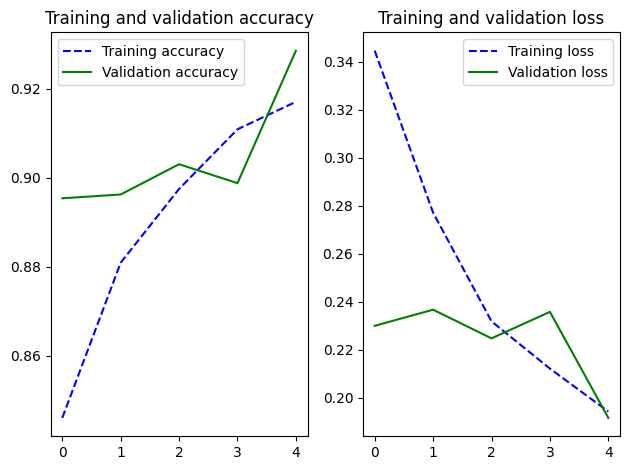

In [25]:
conv_base = VGG16(
    weights = 'imagenet', # We use the network weights already pre-trained on the ImageNet database.
    include_top = False,  # The Dense part of the original network is not retained
    input_shape = (img_width, img_height, 3)
)

conv_base.summary()

# Construction de la tête de classification
vgg_combined= Sequential()
vgg_combined.add(Input(shape=(img_width, img_height, 3)))
vgg_combined.add(conv_base)
vgg_combined.add(Flatten())
vgg_combined.add(Dense(256, activation='relu'))
vgg_combined.add(Dropout(0.2))
vgg_combined.add(Dense(1, activation='sigmoid'))

conv_base.trainable=False

vgg_combined.summary()

# Compilation
epochs = 5
vgg_combined.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

# Entraînement

t_learning_vgg_combined = time.time()

vgg_combined_history = vgg_combined.fit(
    train_gen_aug, 
    validation_data= val_generator,
    epochs=epochs,
)
t_prediction_vgg_combined = time.time()

score_vgg_combined_train = vgg_combined.evaluate(train_gen_aug)
score_vgg_combined_validation = vgg_combined.evaluate(val_generator)

t_prediction_vgg_combined = time.time() - t_prediction_vgg_combined

print('Train accuracy:', score_vgg_combined_train[1])
print('Validation accuracy:', score_vgg_combined_validation[1])
print("Time Prediction: %.2f seconds" % t_prediction_vgg_combined )
plot_training_analysis(vgg_combined_history)

L'utilisation de VGG16 permet de bénéficier immédiatement de filtres visuels complexes (détection de textures, formes, contours) appris sur ImageNet. En injectant la Data Augmentation en amont de ce réseau, nous forçons le classifieur final (la tête dense) à devenir invariant aux transformations géométriques. Le modèle n'apprend plus à reconnaître un chat uniquement dans une position statique, mais apprend à identifier les caractéristiques d'un chat (oreilles, museau) indépendamment du zoom, de la rotation ou du cadrage de l'image.

Le principal défi des réseaux profonds est le sur-apprentissage (overfitting), où le modèle mémorise le bruit des données d'entraînement. En modifiant aléatoirement les images à chaque époque via le générateur, nous simulons un jeu de données virtuellement infini. Cela oblige le modèle à généraliser plutôt qu'à mémoriser, garantissant ainsi que les performances observées sur le jeu de validation reflètent une réelle capacité à traiter des données inconnues.

Bien que le modèle actuel soit performant, il reste limité par le fait que la base VGG16 est "figée" sur ses connaissances d'origine (ImageNet). Le passage au Fine-Tuning (affinement) est l'évolution logique pour maximiser la précision :

- Actuellement, VGG16 extrait des caractéristiques génériques utiles pour 1000 classes d'objets (voitures, fruits, animaux, etc.). En "dégelant" les dernières couches convolutionnelles, nous permettons au réseau d'adapter ses filtres les plus profonds spécifiquement aux spécificités morphologiques des chats et des chiens du dataset Oxford.

- Le Fine-Tuning permet de passer d'une reconnaissance basée sur des formes globales à une reconnaissance de détails subtils propres aux races présentes dans le dataset. Cela permet souvent de corriger les erreurs résiduelles sur les cas difficiles (images ambiguës ou de mauvaise qualité) que l'extracteur générique ne parvenait pas à discriminer parfaitement.

#### Fine tuning

In [26]:
conv_base.trainable = True

for layer in conv_base.layers[:4]:
    layer.trainable = False

vgg_combined.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,007,685 (80.14 MB)

 Trainable params: 16,773,633 (63.99 MB)

 Non-trainable params: 38,720 (151.25 KB)

 Optimizer params: 4,195,332 (16.00 MB)

In [27]:
epochs = 5

vgg_combined.compile(
    loss = 'binary_crossentropy',
    optimizer = Adam(learning_rate=1e-5), # Reduced learning rates to avoid smashing everything and risking overfitting
    metrics = ['accuracy']
)

t_learning_vgg_combined_tuned = time.time()
vgg_combined_tuned_history = vgg_combined.fit(
    train_gen_aug,
    validation_data = val_generator,
    epochs = epochs
)
t_learning_vgg_combined_tuned = time.time() - t_learning_vgg_combined_tuned

print("Learning time for %d epochs : %d seconds" % (epochs, t_learning_vgg_combined_tuned))

Epoch 1/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 45s 146ms/step - accuracy: 0.9291 - loss: 0.1529 - val_accuracy: 0.9617 - val_loss: 0.0946
Epoch 2/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 126ms/step - accuracy: 0.9698 - loss: 0.0812 - val_accuracy: 0.9490 - val_loss: 0.1233
Epoch 3/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.9795 - loss: 0.0590 - val_accuracy: 0.9711 - val_loss: 0.0725
Epoch 4/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - accuracy: 0.9866 - loss: 0.0357 - val_accuracy: 0.9736 - val_loss: 0.0779
Epoch 5/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 33s 141ms/step - accuracy: 0.9873 - loss: 0.0342 - val_accuracy: 0.9685 - val_loss: 0.0817
Learning time for 5 epochs : 167 seconds


236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - accuracy: 0.9926 - loss: 0.0236
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.9646 - loss: 0.0881
Train accuracy: 0.9923453330993652
Validation accuracy: 0.9685373902320862
Time Prediction: 33.64 seconds


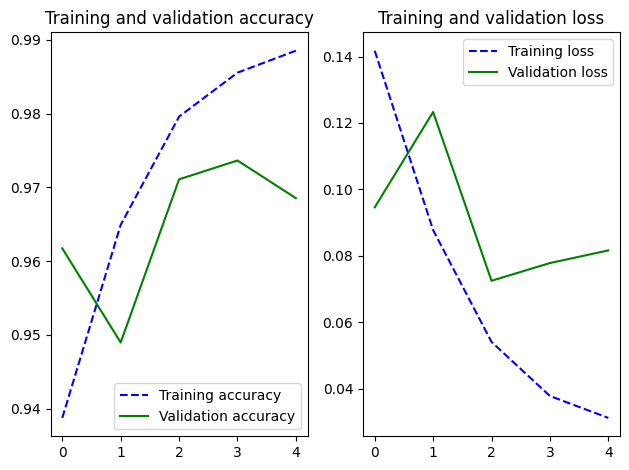

In [28]:
t_prediction_vgg_combined_tuned = time.time()

score_vgg_combined_tuned_train = vgg_combined.evaluate(train_gen_aug)
score_vgg_combined_tuned_validation = vgg_combined.evaluate(val_generator)

t_prediction_vgg_combined_tuned = time.time() - t_prediction_vgg_combined_tuned

print('Train accuracy:', score_vgg_combined_tuned_train[1])
print('Validation accuracy:', score_vgg_combined_tuned_validation[1])
print("Time Prediction: %.2f seconds" % t_prediction_vgg_combined_tuned )
plot_training_analysis(vgg_combined_tuned_history)

On observe un début de sur-apprentissage (overfitting). Bien que la précision de validation soit excellente (autour de 95%), la courbe de perte (Loss) de validation montre une instabilité et diverge de la perte d'entraînement. Malgré plusieurs tentatives pour limiter le surapprentissage, nous n'avons pas réussi=> fine tunning trop puissant pour notre jeu de données. 

On décide donc de garder le modèle VGG_COMBINED.

#### Inférence sur le jeu de test

In [29]:
t_test = time.time()

score_test = vgg_combined.evaluate(test_generator, verbose=1)

t_test = time.time() - t_test

print("===== Résultats Test Final =====")
print("Test loss :", score_test[0])
print("Test accuracy :", score_test[1])
print("Time Test: %.2f seconds" % t_test)

74/74 ━━━━━━━━━━━━━━━━━━━━ 35s 473ms/step - accuracy: 0.9770 - loss: 0.0822
===== Résultats Test Final =====
Test loss : 0.10387486219406128
Test accuracy : 0.9714285731315613
Time Test: 35.71 seconds


74/74 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step


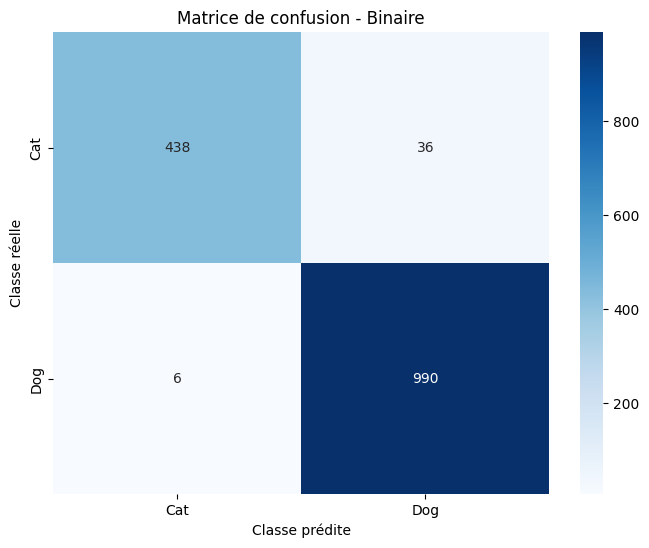

              precision    recall  f1-score   support

         Cat       0.99      0.92      0.95       474
         Dog       0.96      0.99      0.98       996

    accuracy                           0.97      1470
   macro avg       0.98      0.96      0.97      1470
weighted avg       0.97      0.97      0.97      1470



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

test_generator.reset() 


y_true_test = test_generator.classes

pred_test = vgg_combined.predict(test_generator, verbose=1)


# Si proba > 0.5 -> Classe 1, sinon Classe 0
y_pred_test = (pred_test > 0.5).astype(int).flatten()

labels = list(test_generator.class_indices.keys())

# Matrice de confusion
cm_test = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(8, 6)) # Taille réduite car 2x2 suffit pour du binaire
sns.heatmap(cm_test, annot=True, fmt='d', cmap="Blues", 
            xticklabels=labels, yticklabels=labels)

plt.title("Matrice de confusion - Binaire")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()


print(classification_report(y_true_test, y_pred_test, target_names=labels))

74/74 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step
Nombre d'erreurs : 42 / 1470


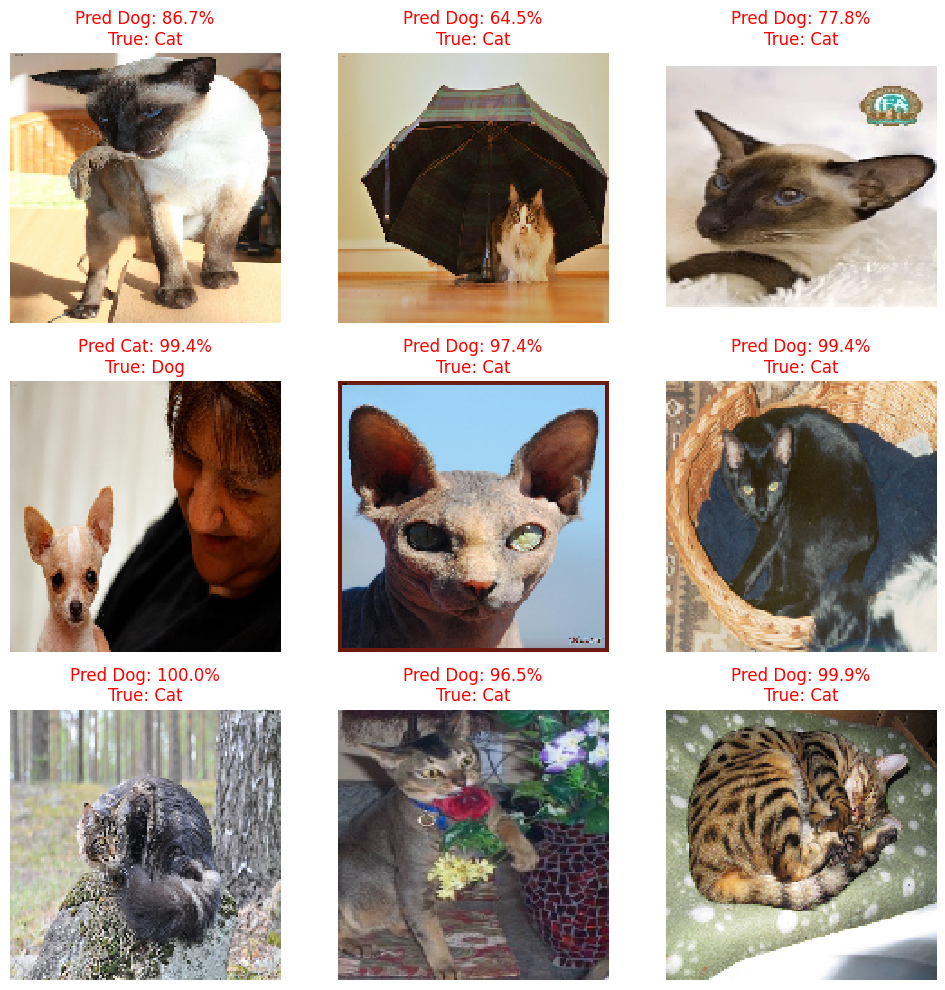

In [ ]:
test_preds = vgg_combined.predict(test_generator)
y_true = test_generator.classes  # classes réelles
y_pred = (test_preds > 0.5).astype(int).flatten()  # prédictions binaires

# Identifier les erreurs
error_idx = np.where(y_true != y_pred)[0]
print(f"Nombre d'erreurs : {len(error_idx)} / {len(y_true)}")

# Visualiser quelques erreurs
n_errors_to_show = min(9, len(error_idx))
selected_errors = np.random.choice(error_idx, size=n_errors_to_show, replace=False)

fig = plt.figure(figsize=(10,10))

for i, idx in enumerate(selected_errors):
    # Charger l'image
    img = img_to_array(load_img(test_generator.filepaths[idx], target_size=(img_width, img_height)))/255
    
    pred_prob = test_preds[idx][0]
    
    ax = fig.add_subplot(3,3,i+1)
    ax.imshow(img, interpolation='nearest')
    
    if pred_prob > 0.5:
        title = f"Pred Dog: {pred_prob*100:.1f}%\nTrue: {'Dog' if y_true[idx]==1 else 'Cat'}"
        color = "red" if y_true[idx]==0 else "green"
    else:
        title = f"Pred Cat: {(1-pred_prob)*100:.1f}%\nTrue: {'Cat' if y_true[idx]==0 else 'Dog'}"
        color = "red" if y_true[idx]==1 else "green"
    
    ax.set_title(title, color=color)
    ax.axis("off")

plt.tight_layout()
plt.show()


## 4. Classification fine

#### A. Pre processing 

In [32]:
# On sépare le dataset en Train / Validation / Test
# Ici, on stratifie selon la race (BREED_NAME) pours'assurer que chaque race est bien représentée dans tous les sous-ensembles.

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['BREED_NAME']
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['BREED_NAME']
)

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")
print("Nombre de races:", train_df["BREED_NAME"].nunique())



Train: 4703 | Validation: 1176 | Test: 1470
Nombre de races: 37


Le mode categorical transforme automatiquement les labels en vecteurs one-hot de taille 37. Cela impose l’utilisation d’une activation softmax et de la fonction de perte categorical cross-entropy. (d'ou le fait qu'on rescale)

In [34]:
# Paramètres généraux
batch_size = 20
img_height = 150
img_width = 150

# Générateur d'entraînement
# On applique un rescaling pour normaliser les pixels entre 0 et 1
train_datagen = ImageDataGenerator(rescale=1./255)

# Générateur validation et test (sans augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Chargement des images d'entraînement
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',          # la cible est maintenant la race
    target_size=(img_height, img_width),
    class_mode='categorical',    # multi-classe → one-hot encoding
    batch_size=batch_size,
    shuffle=True #Éviter d’apprendre l’ordre des données)
)
    
# Validation
val_generator = val_datagen.flow_from_dataframe(
    val_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_height, img_width),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

# Test
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_height, img_width),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False)

num_classes = len(train_generator.class_indices) 
print("Nombre de classes:", num_classes)

Found 4703 validated image filenames belonging to 37 classes.
Found 1176 validated image filenames belonging to 37 classes.
Found 1470 validated image filenames belonging to 37 classes.
Nombre de classes: 37


### B. Modèle CNN 

In [35]:
def cnn_simple_multiclass(nom, num_classes):
    # Même idée que ton cnn_simple binaire, mais sortie multi-classe
    cnn = Sequential(name=nom)
    cnn.add(Input(shape=(img_width, img_height, 3)))

    cnn.add(Conv2D(32, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(64, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(96, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Flatten())
    cnn.add(Dense(64, activation='relu'))

    # IMPORTANT : en multi-classe => num_classes neurones + softmax
    cnn.add(Dense(num_classes, activation='softmax'))

    return cnn


In [36]:
def Entrainement_multiclass(cnn, train_generator, val_generator, epochs=10, learn_rate=3e-4):
    print("Entrainement de", cnn.name)

    # En multi-classe avec one-hot => categorical_crossentropy
    cnn.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(learning_rate=learn_rate),
        metrics=['accuracy']
    )

    t_learning_cnn = time.time()

    cnn_history = cnn.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs
    )

    t_learning_cnn = time.time() - t_learning_cnn
    print("Learning time for %d epochs : %d seconds" % (epochs, t_learning_cnn))

    return t_learning_cnn, cnn_history


In [37]:
def plot_training_analysis(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', linestyle="--", label='Training accuracy')
    plt.plot(epochs, val_acc, 'g', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', linestyle="--", label='Training loss')
    plt.plot(epochs, val_loss, 'g', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [38]:
def Analyse_resultats_multiclass(cnn, train_generator, val_generator, cnn_history):

    t_prediction_cnn = time.time()

    score_cnn_train = cnn.evaluate(train_generator, verbose=1)
    score_cnn_validation = cnn.evaluate(val_generator, verbose=1)

    t_prediction_cnn = time.time() - t_prediction_cnn

    print('Train accuracy:', score_cnn_train[1])
    print('Validation accuracy:', score_cnn_validation[1])
    print("Time Prediction: %.2f seconds" % t_prediction_cnn)

    plot_training_analysis(cnn_history)

    return t_prediction_cnn

Model: "cnn_multiclass_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 27744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     1,775,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,852,869 (7.07 MB)

 Trainable params: 1,852,869 (7.07 MB)

 Non-trainable params: 0 (0.00 B)

Entrainement de cnn_multiclass_simple
Epoch 1/10


/home/j_lauren/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


236/236 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.0351 - loss: 3.6119 - val_accuracy: 0.0493 - val_loss: 3.5866
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - accuracy: 0.0548 - loss: 3.5326 - val_accuracy: 0.0876 - val_loss: 3.3930
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 17s 73ms/step - accuracy: 0.1387 - loss: 3.2346 - val_accuracy: 0.1148 - val_loss: 3.2215
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.2021 - loss: 2.9444 - val_accuracy: 0.1471 - val_loss: 3.2038
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 91ms/step - accuracy: 0.2911 - loss: 2.5624 - val_accuracy: 0.1650 - val_loss: 3.1628
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.3911 - loss: 2.1189 - val_accuracy: 0.1633 - val_loss: 3.3159
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 79ms/step - accuracy: 0.5450 - loss: 1.6050 - val_accuracy: 0.1701 - val_loss: 3.4619
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - accuracy: 0.6966 - loss: 1.1127 - val_accurac

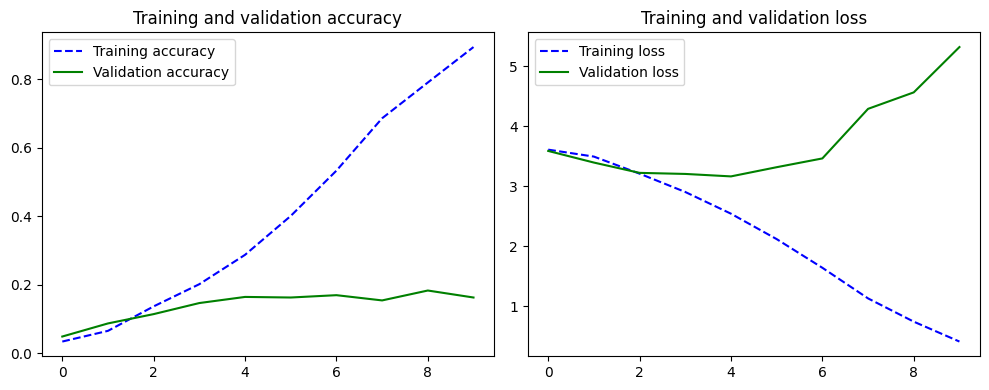

In [39]:
# Nombre de classes (races)
num_classes = len(train_generator.class_indices)

# Création du modèle multi-classe
cnn_mc_naif = cnn_simple_multiclass("cnn_multiclass_simple", num_classes)
cnn_mc_naif.summary()

# Entrainement
t_learning_cnn_mc_naif, cnn_mc_naif_history = Entrainement_multiclass(
    cnn_mc_naif,
    train_generator,
    val_generator,
    epochs=10,
    learn_rate=3e-4
)

# Analyse
t_prediction_cnn_mc_naif = Analyse_resultats_multiclass(
    cnn_mc_naif,
    train_generator,
    val_generator,
    cnn_mc_naif_history
)

Sans dropout, le modèle apprend très bien sur les données d’entraînement mais a tendance à surapprendre, ce qui se traduit par une baisse ou une stagnation de la précision sur l’ensemble de validation.

#### Ajout de dropout

In [40]:
def cnn_multiclass_dropout(nom, num_classes, drop_rate=0.5):
    # Même architecture que ton CNN simple, mais avec Dropout
    # Objectif : limiter le surapprentissage (overfitting)

    cnn = Sequential(name=nom)
    cnn.add(Input(shape=(img_width, img_height, 3)))

    cnn.add(Conv2D(32, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(64, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Conv2D(96, (3,3), activation='relu'))
    cnn.add(MaxPooling2D(pool_size=(2,2)))

    cnn.add(Flatten())
    cnn.add(Dense(64, activation='relu'))

    # Dropout : pendant l'entraînement, on "éteint" une partie des neurones
    # Cela empêche le réseau de trop se spécialiser sur le train
    cnn.add(Dropout(drop_rate))

    # Sortie multi-classe
    cnn.add(Dense(num_classes, activation='softmax'))

    return cnn


Model: "cnn_multiclass_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 27744)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │     1,775,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,852,869 (7.07 MB)

 Trainable params: 1,852,869 (7.07 MB)

 Non-trainable params: 0 (0.00 B)

Entrainement de cnn_multiclass_dropout
Epoch 1/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 23s 87ms/step - accuracy: 0.0332 - loss: 3.6163 - val_accuracy: 0.0519 - val_loss: 3.6008
Epoch 2/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 81ms/step - accuracy: 0.0525 - loss: 3.5778 - val_accuracy: 0.0910 - val_loss: 3.4673
Epoch 3/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.0680 - loss: 3.4770 - val_accuracy: 0.1241 - val_loss: 3.3573
Epoch 4/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 88ms/step - accuracy: 0.0968 - loss: 3.3110 - val_accuracy: 0.1480 - val_loss: 3.2039
Epoch 5/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 19s 80ms/step - accuracy: 0.1441 - loss: 3.1367 - val_accuracy: 0.1548 - val_loss: 3.1318
Epoch 6/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step - accuracy: 0.1804 - loss: 2.9652 - val_accuracy: 0.1548 - val_loss: 3.1045
Epoch 7/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 89ms/step - accuracy: 0.2024 - loss: 2.7989 - val_accuracy: 0.1701 - val_loss: 3.0524
Epoch 8/20
236/236 ━━━━━━━━━━━━━━━━━━━━ 21s 87ms/st

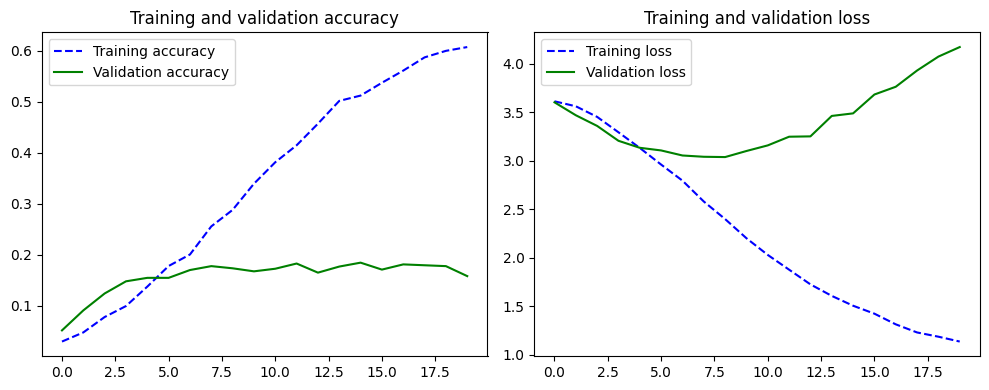

In [41]:
# Nombre de classes (races)
num_classes = len(train_generator.class_indices)

# Création du modèle avec dropout
cnn_mc_do = cnn_multiclass_dropout("cnn_multiclass_dropout", num_classes, drop_rate=0.5)
cnn_mc_do.summary()

# Entrainement (multi-classe)
t_learning_cnn_mc_do, cnn_mc_do_history = Entrainement_multiclass(
    cnn_mc_do,
    train_generator,
    val_generator,
    epochs=20,
    learn_rate=3e-4
)

# Analyse résultats
t_prediction_cnn_mc_do = Analyse_resultats_multiclass(
    cnn_mc_do,
    train_generator,
    val_generator,
    cnn_mc_do_history
)

L’ajout du dropout n’a pas permis de réduire significativement le surapprentissage. Cela s’explique par la complexité du problème (37 classes visuellement proches), la taille limitée du jeu de données et le fait que le dropout n’agit que sur les couches fully-connected, alors que l’extraction des caractéristiques repose principalement sur les couches convolutionnelles. Remarque : La valeur de la fonction de perte n’est pas bornée entre 0 et 1 car la cross-entropy n’est pas une probabilité mais une mesure logarithmique de l’erreur. Une valeur de loss élevée correspond à une faible probabilité attribuée à la classe correcte, ce qui est fréquent en début d’entraînement, en particulier pour un problème multi-classe avec un grand nombre de catégories. Afin de lutter ebcore une fois contre le surapprentisssage, nous llons par la suite faire de la data augmentation.

#### Data Augmentation

Bien que le nombre d’images du jeu d’entraînement reste inchangé, la data augmentation permet de présenter au modèle des versions modifiées des images à chaque itération, augmentant ainsi la diversité effective des données.

In [42]:
# Data augmentation : on augmente artificiellement la diversité des images
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.15,
    horizontal_flip=True
)

train_generator_aug = train_datagen_aug.flow_from_dataframe(
    train_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_width, img_height),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

Found 4703 validated image filenames belonging to 37 classes.


Entrainement de cnn_multiclass_dropout


/home/j_lauren/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 33s 130ms/step - accuracy: 0.1312 - loss: 3.5732 - val_accuracy: 0.1718 - val_loss: 3.1243
Epoch 2/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.1664 - loss: 3.1018 - val_accuracy: 0.1760 - val_loss: 3.0720
Epoch 3/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 28s 117ms/step - accuracy: 0.1671 - loss: 3.0894 - val_accuracy: 0.1854 - val_loss: 2.9738
Epoch 4/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.1705 - loss: 3.0115 - val_accuracy: 0.1845 - val_loss: 3.0048
Epoch 5/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 28s 118ms/step - accuracy: 0.1823 - loss: 2.9785 - val_accuracy: 0.1998 - val_loss: 2.9756
Epoch 6/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.1973 - loss: 2.8963 - val_accuracy: 0.1964 - val_loss: 2.9402
Epoch 7/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 127ms/step - accuracy: 0.2042 - loss: 2.8822 - val_accuracy: 0.1862 - val_loss: 2.9130
Epoch 8/30
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 122ms/step - accuracy: 0.2033 - loss: 2

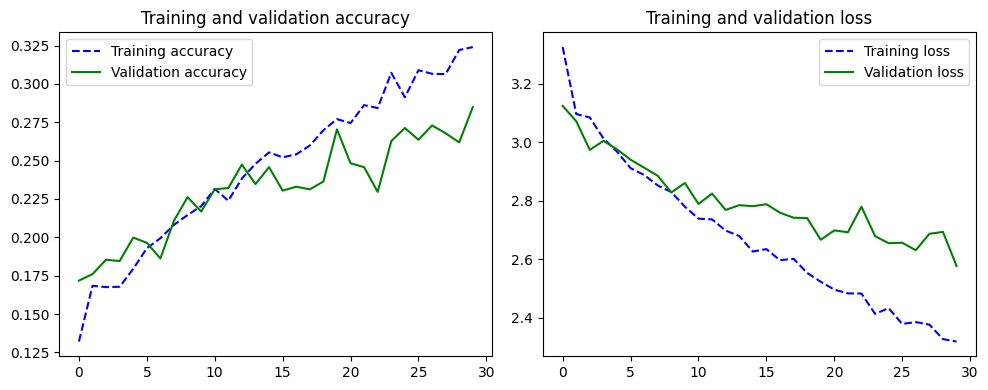

In [43]:
t_learning_cnn_mc_do_aug, cnn_mc_do_aug_history = Entrainement_multiclass(
    cnn_mc_do,
    train_generator_aug,
    val_generator,
    epochs=30,
    learn_rate=3e-4)

t_prediction_cnn_mc_do_aug = Analyse_resultats_multiclass(
    cnn_mc_do,
    train_generator_aug,
    val_generator,
    cnn_mc_do_aug_history)

On augmente le nombre d’epochs parce que la data augmentation rend la tâche plus variée, donc l’entraînement peut prendre plus de temps à converger. Ici il surapprend moins mais on va tester du transfer learning pour voir si on fait mieux.

### C. Pre trained network : Utilisation de VGG 16

In [44]:
from tensorflow.keras.applications.vgg16 import preprocess_input

train_datagen_vgg = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen_vgg = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_vgg = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_vgg = train_datagen_vgg.flow_from_dataframe(
    train_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_width, img_height),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_generator_vgg = val_datagen_vgg.flow_from_dataframe(
    val_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_width, img_height),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_generator_vgg = test_datagen_vgg.flow_from_dataframe(
    test_df,
    img_dir,
    x_col='Image',
    y_col='BREED_NAME',
    target_size=(img_width, img_height),
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

num_classes = len(train_generator_vgg.class_indices)
print("Nombre de classes :", num_classes)

Found 4703 validated image filenames belonging to 37 classes.
Found 1176 validated image filenames belonging to 37 classes.
Found 1470 validated image filenames belonging to 37 classes.
Nombre de classes : 37


Dans le cadre du transfer learning avec VGG16, les images sont pré-traitées à l’aide de la fonction preprocess_input, afin de reproduire les conditions exactes d’entraînement du réseau sur ImageNet. L’utilisation d’un simple rescaling n’est pas appropriée dans ce cas, car elle modifierait la distribution des pixels attendue par le modèle pré-entraîné.

In [45]:
conv_base = VGG16(
    weights='imagenet',      # on récupère les poids ImageNet
    include_top=False,       # on enlève la partie Dense originale
    input_shape=(img_width, img_height, 3)
)

conv_base.summary()

# On gèle le backbone : on entraîne seulement la "tête" au début
conv_base.trainable = False

# Construction du modèle complet : VGG16 + head
vgg_combined_mc = Sequential(name="VGG16_multiclass_head")
vgg_combined_mc.add(Input(shape=(img_width, img_height, 3)))
vgg_combined_mc.add(conv_base)
vgg_combined_mc.add(Flatten())
vgg_combined_mc.add(Dense(256, activation='relu'))

# Option dropout (on pourrait sans et je l'ai fait mais ca surapprend un peu donc je le mets)
vgg_combined_mc.add(Dropout(0.3))

# Sortie multi-classe : softmax + num_classes neurones
vgg_combined_mc.add(Dense(num_classes, activation='softmax'))

vgg_combined_mc.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Model: "VGG16_multiclass_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,821,605 (64.17 MB)

 Trainable params: 2,106,917 (8.04 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [46]:
epochs = 5

# En multi-classe : categorical_crossentropy
vgg_combined_mc.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=3e-4),
    metrics=['accuracy']
)

t_learning_vgg_mc = time.time()

vgg_combined_mc_history = vgg_combined_mc.fit(
    train_generator_vgg,
    validation_data=val_generator_vgg,
    epochs=epochs
)

t_learning_vgg_mc = time.time() - t_learning_vgg_mc
print("Learning time :", int(t_learning_vgg_mc), "sec")


/home/j_lauren/.local/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


2026-01-19 18:33:24.300064: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1152', 584 bytes spill stores, 584 bytes spill loads

2026-01-19 18:33:24.450009: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1201', 16 bytes spill stores, 16 bytes spill loads



206/236 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.1659 - loss: 16.0166

2026-01-19 18:33:47.777300: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1152', 324 bytes spill stores, 324 bytes spill loads



236/236 ━━━━━━━━━━━━━━━━━━━━ 35s 137ms/step - accuracy: 0.1700 - loss: 14.8667 - val_accuracy: 0.3214 - val_loss: 2.7163
Epoch 2/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 30s 125ms/step - accuracy: 0.3106 - loss: 2.7501 - val_accuracy: 0.5060 - val_loss: 2.1481
Epoch 3/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 124ms/step - accuracy: 0.4607 - loss: 2.1558 - val_accuracy: 0.5502 - val_loss: 1.8339
Epoch 4/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 122ms/step - accuracy: 0.5194 - loss: 1.8675 - val_accuracy: 0.6207 - val_loss: 1.6573
Epoch 5/5
236/236 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.5713 - loss: 1.6247 - val_accuracy: 0.6488 - val_loss: 1.4757
Learning time : 151 sec


Lors de la phase de transfer learning, seules quelques époques sont nécessaires pour entraîner la tête de classification, le backbone VGG16 étant déjà pré-entraîné sur ImageNet. Cette phase permet de stabiliser les poids avant d’effectuer un fine-tuning plus fin du modèle.

236/236 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - accuracy: 0.7359 - loss: 0.9394
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.6601 - loss: 1.3071
Train accuracy: 0.7359132170677185
Validation accuracy: 0.648809552192688
Time Prediction: 29.47 seconds


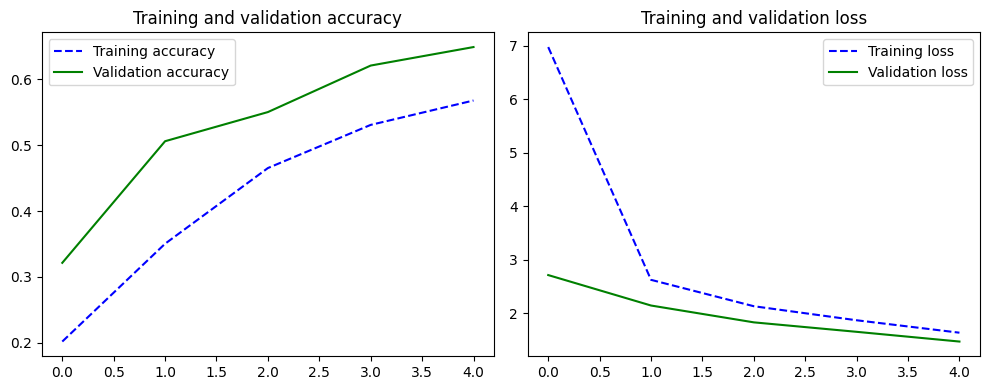

In [47]:
t_prediction_vgg_mc = time.time()

score_vgg_mc_train = vgg_combined_mc.evaluate(train_generator_vgg, verbose=1)
score_vgg_mc_validation = vgg_combined_mc.evaluate(val_generator_vgg, verbose=1)

t_prediction_vgg_mc = time.time() - t_prediction_vgg_mc

print('Train accuracy:', score_vgg_mc_train[1])
print('Validation accuracy:', score_vgg_mc_validation[1])
print("Time Prediction: %.2f seconds" % t_prediction_vgg_mc)

plot_training_analysis(vgg_combined_mc_history)


Lors de la phase de transfer learning, la fonction de perte est initialement élevée en raison de l’initialisation aléatoire de la tête de classification. Elle diminue rapidement car le backbone pré-entraînmé fournit des caractéristiques visuelles pertinentes, permettant à la tête de s’adapter efficacement au jeu de données.

#### Fine-tuning

Nombre de couches VGG entraînables : 1
Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 32s 128ms/step - accuracy: 0.6226 - loss: 1.3702 - val_accuracy: 0.6497 - val_loss: 1.4681
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 31s 131ms/step - accuracy: 0.6282 - loss: 1.3790 - val_accuracy: 0.6497 - val_loss: 1.4583
Epoch 3/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 121ms/step - accuracy: 0.6214 - loss: 1.3809 - val_accuracy: 0.6497 - val_loss: 1.4494
Epoch 4/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 27s 115ms/step - accuracy: 0.6523 - loss: 1.2913 - val_accuracy: 0.6590 - val_loss: 1.4412
Epoch 5/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 122ms/step - accuracy: 0.6291 - loss: 1.3536 - val_accuracy: 0.6616 - val_loss: 1.4357
Epoch 6/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.6413 - loss: 1.3286 - val_accuracy: 0.6684 - val_loss: 1.4307
Epoch 7/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 28s 120ms/step - accuracy: 0.6321 - loss: 1.3342 - val_accuracy: 0.6684 - val_loss: 1.4247
Epoch 8/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 27s 

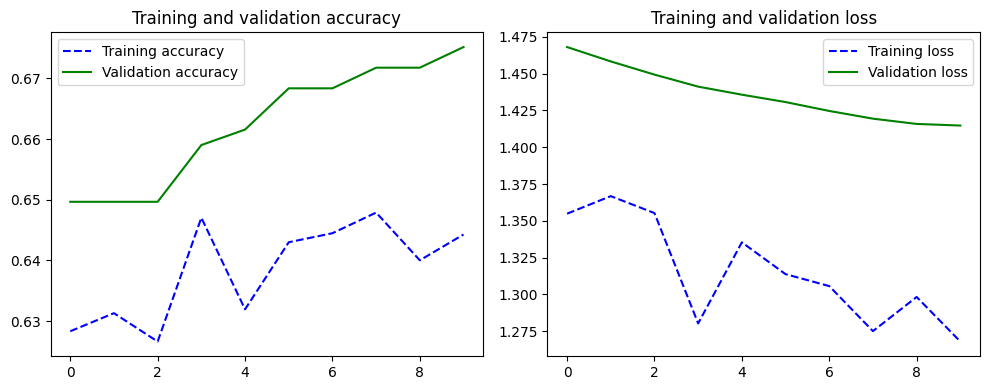

In [48]:
# On dégèle le backbone (mais pas tout)
conv_base.trainable = True

# On garde gelées les premières couches, et on n'entraîne que les dernières
for layer in conv_base.layers[:-1]:
    layer.trainable = False

print("Nombre de couches VGG entraînables :", sum([l.trainable for l in conv_base.layers]))

# IMPORTANT : LR faible pour fine-tuning
vgg_combined_mc.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-6),
    metrics=['accuracy']
)

epochs_ft = 10
t_learning_vgg_mc_ft = time.time()

vgg_mc_ft_history = vgg_combined_mc.fit(
    train_generator_vgg,
    validation_data=val_generator_vgg,
    epochs=epochs_ft
)

t_learning_vgg_mc_ft = time.time() - t_learning_vgg_mc_ft
print("Learning time fine-tuning :", int(t_learning_vgg_mc_ft), "sec")

# Analyse après fine-tuning
t_pred_vgg_mc_ft = Analyse_resultats_multiclass(
    vgg_combined_mc,
    train_generator_vgg,
    val_generator_vgg,
    vgg_mc_ft_history
)

Malgré une stratégie de fine-tuning progressive (dégel d’une seule couche et learning rate très faible), le modèle présente un surapprentissage important. Ce comportement s’explique par la capacité élevée du backbone VGG16 par rapport à la taille du jeu de données. Le transfer learning sans fine-tuning constitue donc la meilleure approche dans notre cas.

#### Inférence sur le jeu de test

In [49]:
t_test = time.time()

score_test = vgg_combined_mc.evaluate(test_generator_vgg, verbose=1)

t_test = time.time() - t_test

print("===== Résultats Test Final =====")
print("Test loss :", score_test[0])
print("Test accuracy :", score_test[1])
print("Time Test: %.2f seconds" % t_test)

74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.6385 - loss: 1.3851
===== Résultats Test Final =====
Test loss : 1.4279247522354126
Test accuracy : 0.6517006754875183
Time Test: 6.49 seconds


74/74 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step


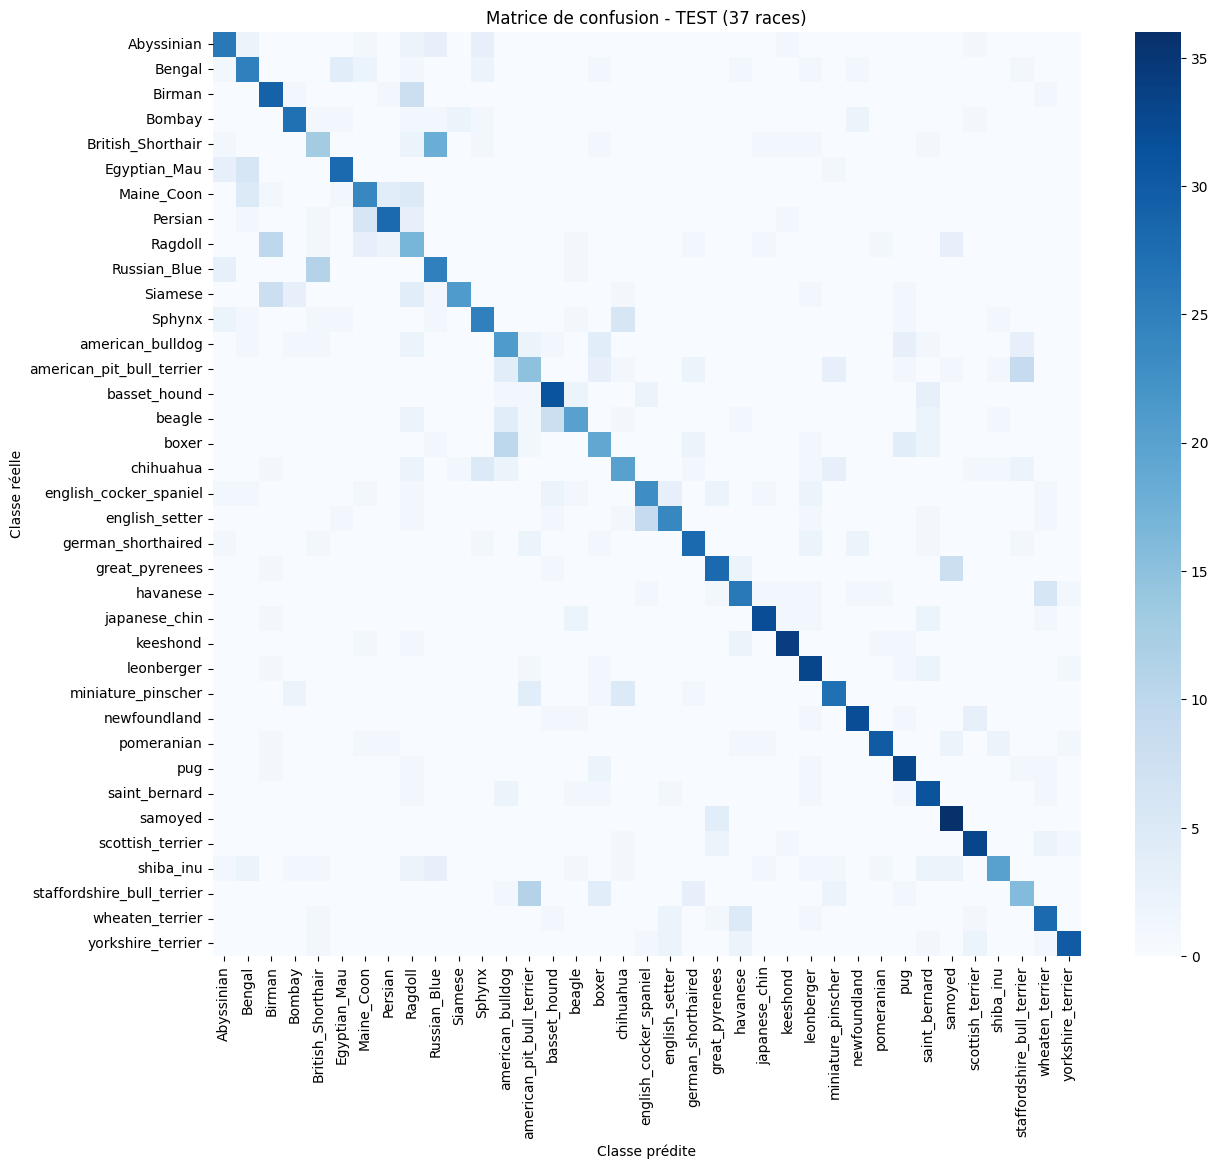

                            precision    recall  f1-score   support

                Abyssinian       0.67      0.67      0.67        39
                    Bengal       0.57      0.62      0.60        40
                    Birman       0.54      0.72      0.62        40
                    Bombay       0.77      0.73      0.75        37
         British_Shorthair       0.39      0.33      0.36        40
              Egyptian_Mau       0.78      0.74      0.76        38
                Maine_Coon       0.62      0.60      0.61        40
                   Persian       0.78      0.70      0.74        40
                   Ragdoll       0.30      0.42      0.35        40
              Russian_Blue       0.47      0.62      0.54        40
                   Siamese       0.88      0.53      0.66        40
                    Sphynx       0.66      0.62      0.64        40
          american_bulldog       0.47      0.53      0.49        40
 american_pit_bull_terrier       0.39      0.38

In [50]:
from sklearn.metrics import confusion_matrix, classification_report

# Liste des labels dans l'ordre des indices Keras
labels = list(test_generator_vgg.class_indices.keys())

# Vraies classes (ids)
y_true_test = test_generator_vgg.classes

# Prédictions
pred_test = vgg_combined_mc.predict(test_generator_vgg, verbose=1)
y_pred_test = np.argmax(pred_test, axis=1)

# Matrice de confusion
cm_test = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(14,12))
sns.heatmap(cm_test, cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Matrice de confusion - TEST (37 races)")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

# Rapport détaillé par race (precision/recall/f1)
print(classification_report(y_true_test, y_pred_test, target_names=labels))

## 5. Segmentation

In [51]:
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

### A. Chargement des Données

In [ ]:

base_path = "./oxford-iiit-pet/"
img_dir = os.path.join(base_path, "images/")
mask_dir = os.path.join(base_path, "annotations/trimaps/")

# --- Ajout de la colonne des masques ---

df['mask_filename'] = df['Image'].str.replace('.jpg', '.png')


# --- Division du Dataset (Train / Val / Test) ---
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['SPECIES_NAME'])
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['SPECIES_NAME'])

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")

Train: 4703 | Validation: 1176 | Test: 1470


In [ ]:
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def load_data_in_ram(df, img_dir, mask_dir, img_size=(128, 128)):
    images = []
    masks = []
    
    print(f"Chargement de {len(df)} images en cours...")
    
    count = 0
    for _, row in df.iterrows():
        # Chargement Image
        img_path = os.path.join(img_dir, row['Image'])
        img = load_img(img_path, target_size=img_size)
        images.append(img_to_array(img) / 255.0) # Normalisation [0, 1]
        
        # Chargement Masque
        mask_path = os.path.join(mask_dir, row['mask_filename'])
        mask = load_img(mask_path, target_size=img_size, color_mode="grayscale")
        masks.append(img_to_array(mask) - 1) # Correction classes: 1,2,3 -> 0,1,2
        
        count += 1
        if count % 1000 == 0:
            print(f"{count} images traitées")
            
    return np.array(images), np.array(masks)

# Exécution du chargement
# IMG_SIZE doit correspondre à l'entrée de notre modèle (128, 128)
X_train, y_train = load_data_in_ram(train_df, img_dir, mask_dir)
X_val, y_val = load_data_in_ram(val_df, img_dir, mask_dir)

print("Chargement terminé.")
print(f"X_train shape: {X_train.shape}")

Chargement de 4703 images en cours...
1000 images traitées
2000 images traitées
3000 images traitées
4000 images traitées
Chargement de 1176 images en cours...
1000 images traitées
Chargement terminé.
X_train shape: (4703, 128, 128, 3)


### B. Implémentation du U-Net

L'architecture U-Net standard comprend une voie de contraction (encodeur) et une voie d'expansion (décodeur) avec des connexions résiduelles (skip connections).

In [55]:
def build_unet(input_shape, num_classes):
    inputs = Input(input_shape)

    # --- Encodeur (Contraction) ---
    # Bloc 1
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c1)
    p1 = MaxPooling2D((2, 2))(c1)

    # Bloc 2
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c2)
    p2 = MaxPooling2D((2, 2))(c2)

    # Bloc 3
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c3)
    p3 = MaxPooling2D((2, 2))(c3)

    # --- Bottleneck ---
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c4)
    c4 = Dropout(0.3)(c4) # Pour éviter le surapprentissage

    # --- Décodeur (Expansion) ---
    # Bloc 5 (Up 1)
    u5 = UpSampling2D((2, 2))(c4)
    u5 = Concatenate()([u5, c3]) # Skip Connection
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u5)
    c5 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c5)

    # Bloc 6 (Up 2)
    u6 = UpSampling2D((2, 2))(c5)
    u6 = Concatenate()([u6, c2]) # Skip Connection
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u6)
    c6 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c6)

    # Bloc 7 (Up 3)
    u7 = UpSampling2D((2, 2))(c6)
    u7 = Concatenate()([u7, c1]) # Skip Connection
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(u7)
    c7 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(c7)

    # --- Sortie ---
    # 3 classes : Animal, Background, Border -> Softmax
    outputs = Conv2D(num_classes, (1, 1), activation='softmax')(c7)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model
    
img_size=(128, 128)
# Construction du modèle
model = build_unet(input_shape=img_size + (3,), num_classes=3)
# model.summary()

### C. Définition des métriques

Pour compiler le modèle, nous devons définir des métriques adaptées à la segmentation sémantique.

In [56]:
def dice_coef(y_true, y_pred, smooth=1):
    # On convertit les étiquettes en one-hot pour correspondre à la sortie softmax
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=3)
    y_true_one_hot = tf.reshape(y_true_one_hot, shape=tf.shape(y_pred))
    
    intersection = K.sum(y_true_one_hot * y_pred, axis=[0,1,2])
    union = K.sum(y_true_one_hot, axis=[0,1,2]) + K.sum(y_pred, axis=[0,1,2])
    return K.mean( (2. * intersection + smooth) / (union + smooth) )

def iou_coef(y_true, y_pred, smooth=1):
    y_true_one_hot = tf.one_hot(tf.cast(y_true, tf.int32), depth=3)
    y_true_one_hot = tf.reshape(y_true_one_hot, shape=tf.shape(y_pred))
    
    intersection = K.sum(K.abs(y_true_one_hot * y_pred), axis=[0,1,2])
    union = K.sum(y_true_one_hot,[0,1,2]) + K.sum(y_pred,[0,1,2]) - intersection
    return K.mean((intersection + smooth) / (union + smooth))

### D. Entraînement

In [57]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('oxford_unet.keras', save_best_only=True)
]

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy', iou_coef, dice_coef])

history = model.fit(
    x=X_train,
    y=y_train,
    validation_data=(X_val, y_val),
    batch_size=64, 
    epochs=12,
    callbacks=callbacks
)

Epoch 1/12


/home/j_lauren/.local/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_330']
Received: inputs=Tensor(shape=(None, 128, 128, 3))
  warnings.warn(msg)
2026-01-19 18:44:17.433583: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-01-19 18:44:36.675784: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-input.14 = (f32[64,192,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,128,128]{3,2,1,0} %bitcast.11092, f32[64,192,3,3]{3,2,1,0} %bitcast.11029), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/functional_58_1/conv2d_27_1/convolution/Conv2DBackpropInput

73/74 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.5734 - dice_coef: 0.3446 - iou_coef: 0.2272 - loss: 1.3911

2026-01-19 18:45:34.033188: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - accuracy: 0.5742 - dice_coef: 0.3452 - iou_coef: 0.2277 - loss: 1.3855

2026-01-19 18:46:00.141971: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2026-01-19 18:46:15.521966: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert


74/74 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.5748 - dice_coef: 0.3458 - iou_coef: 0.2282 - loss: 1.3800 - val_accuracy: 0.7122 - val_dice_coef: 0.4699 - val_iou_coef: 0.3348 - val_loss: 0.7113
Epoch 2/12
74/74 ━━━━━━━━━━━━━━━━━━━━ 35s 476ms/step - accuracy: 0.7246 - dice_coef: 0.4929 - iou_coef: 0.3534 - loss: 0.6765 - val_accuracy: 0.7423 - val_dice_coef: 0.5250 - val_iou_coef: 0.3864 - val_loss: 0.6363
Epoch 3/12
74/74 ━━━━━━━━━━━━━━━━━━━━ 35s 476ms/step - accuracy: 0.7689 - dice_coef: 0.5565 - iou_coef: 0.4144 - loss: 0.5791 - val_accuracy: 0.7875 - val_dice_coef: 0.5697 - val_iou_coef: 0.4266 - val_loss: 0.5427
Epoch 4/12
74/74 ━━━━━━━━━━━━━━━━━━━━ 35s 476ms/step - accuracy: 0.8014 - dice_coef: 0.6065 - iou_coef: 0.4644 - loss: 0.5070 - val_accuracy: 0.8274 - val_dice_coef: 0.6514 - val_iou_coef: 0.5145 - val_loss: 0.4413
Epoch 5/12
74/74 ━━━━━━━━━━━━━━━━━━━━ 35s 479ms/step - accuracy: 0.8189 - dice_coef: 0.6343 - iou_coef: 0.4938 - loss: 0.4660 - val_accuracy: 0.8296 - va

### E. Visualisation des résultats (jeux de validation et d'entrainement)

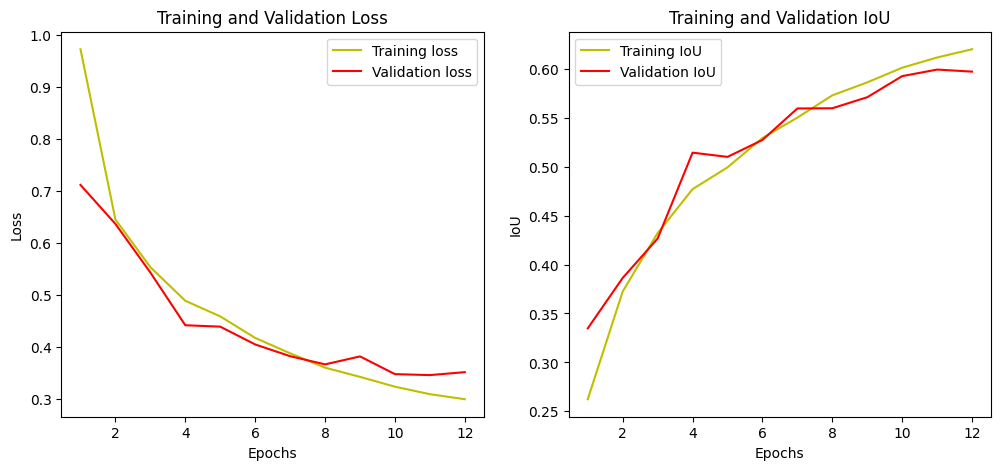

In [58]:
def plot_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    iou = history.history['iou_coef']
    val_iou = history.history['val_iou_coef']
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))
    
    # Courbe de perte
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'y', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Courbe IoU
    plt.subplot(1, 2, 2)
    plt.plot(epochs, iou, 'y', label='Training IoU')
    plt.plot(epochs, val_iou, 'r', label='Validation IoU')
    plt.title('Training and Validation IoU')
    plt.xlabel('Epochs')
    plt.ylabel('IoU')
    plt.legend()

    plt.show()

plot_history(history)

/home/j_lauren/.local/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_330']
Received: inputs=Tensor(shape=(15, 128, 128, 3))
  warnings.warn(msg)


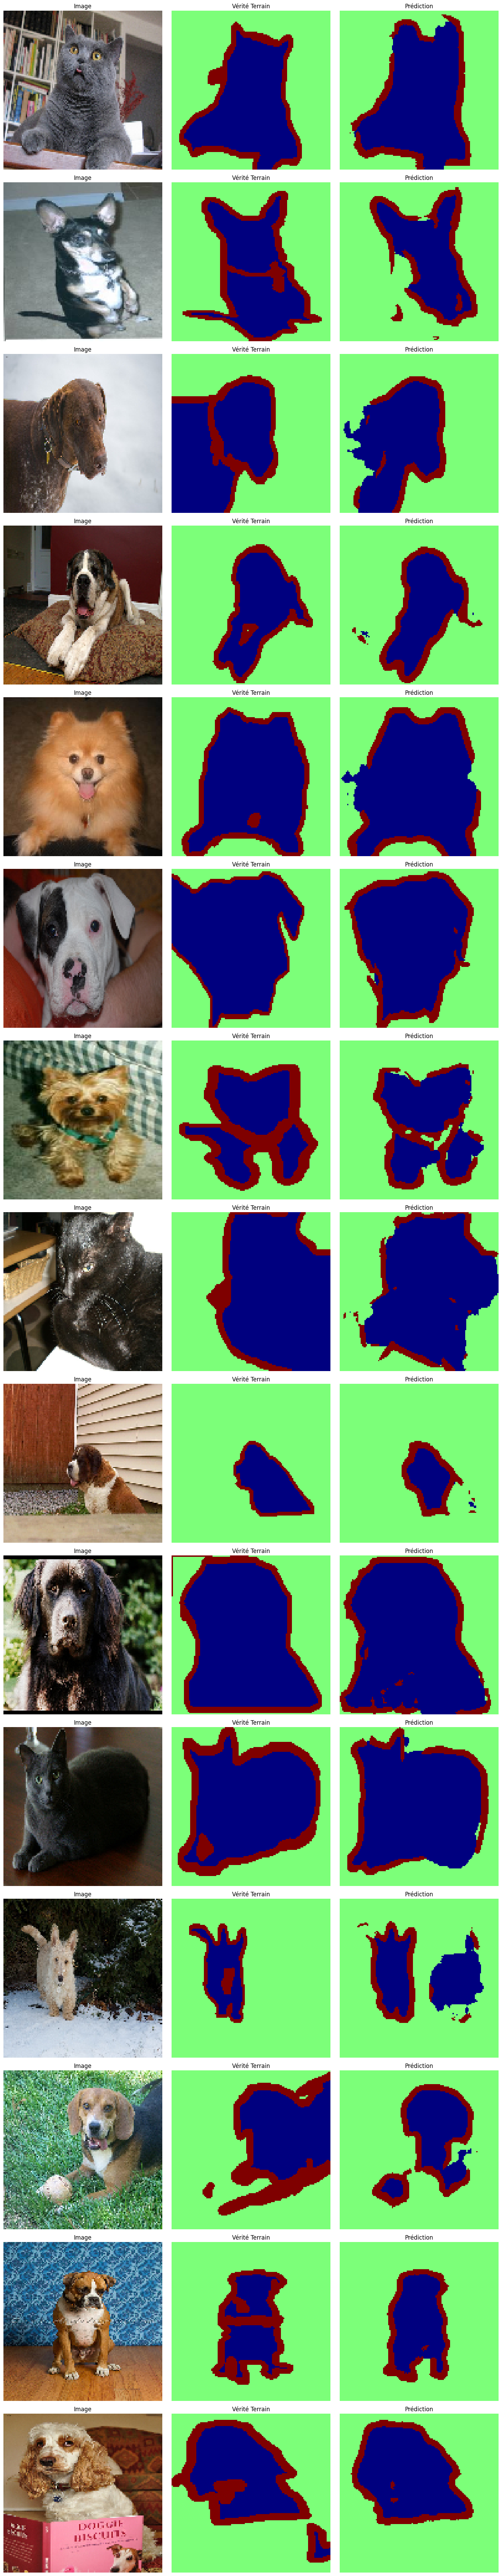

In [59]:
def display_prediction(model, x_data, y_data, num_samples):
    # On découpe les données passées en argument
    # On utilise des noms de variables locales distincts (x_batch, y_batch)
    x_batch = x_data[:num_samples]
    y_batch = y_data[:num_samples]
    
    preds = model.predict(x_batch, verbose=0)
    preds_argmax = np.argmax(preds, axis=-1)
    
    # Gestion du format (Squeeze si nécessaire)
    if y_batch.ndim == 4 and y_batch.shape[-1] == 1:
        y_batch = y_batch.squeeze()
    elif y_batch.ndim == 4 and y_batch.shape[-1] > 1:
        y_batch = np.argmax(y_batch, axis=-1)

    plt.figure(figsize=(15, 5 * num_samples))
    for i in range(num_samples):
        # Image
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(x_batch[i])
        plt.title("Image")
        plt.axis("off")

        # Vérité Terrain
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(y_batch[i], cmap='jet', vmin=0, vmax=2)
        plt.title("Vérité Terrain")
        plt.axis("off")

        # Prédiction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(preds_argmax[i], cmap='jet', vmin=0, vmax=2)
        plt.title("Prédiction")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

# Appel correct de la fonction en passant vos variables globales X_val et y_val
display_prediction(model, X_val, y_val, 15)

### F. Visualisation et Comparaison des performances entre les races sur le jeu de test

#### A. Chargement du jeu de test

In [60]:
# 1. Charger les données de TEST en RAM
# (Utilise la fonction load_data_in_ram définie précédemment)
print("Chargement des données de test...")
X_test, y_test = load_data_in_ram(test_df, img_dir, mask_dir)

print(f"Données de test chargées : {X_test.shape}")

Chargement des données de test...
Chargement de 1470 images en cours...
1000 images traitées
Données de test chargées : (1470, 128, 128, 3)


####  B. Visualisation de la segmentation sur le jeu de test

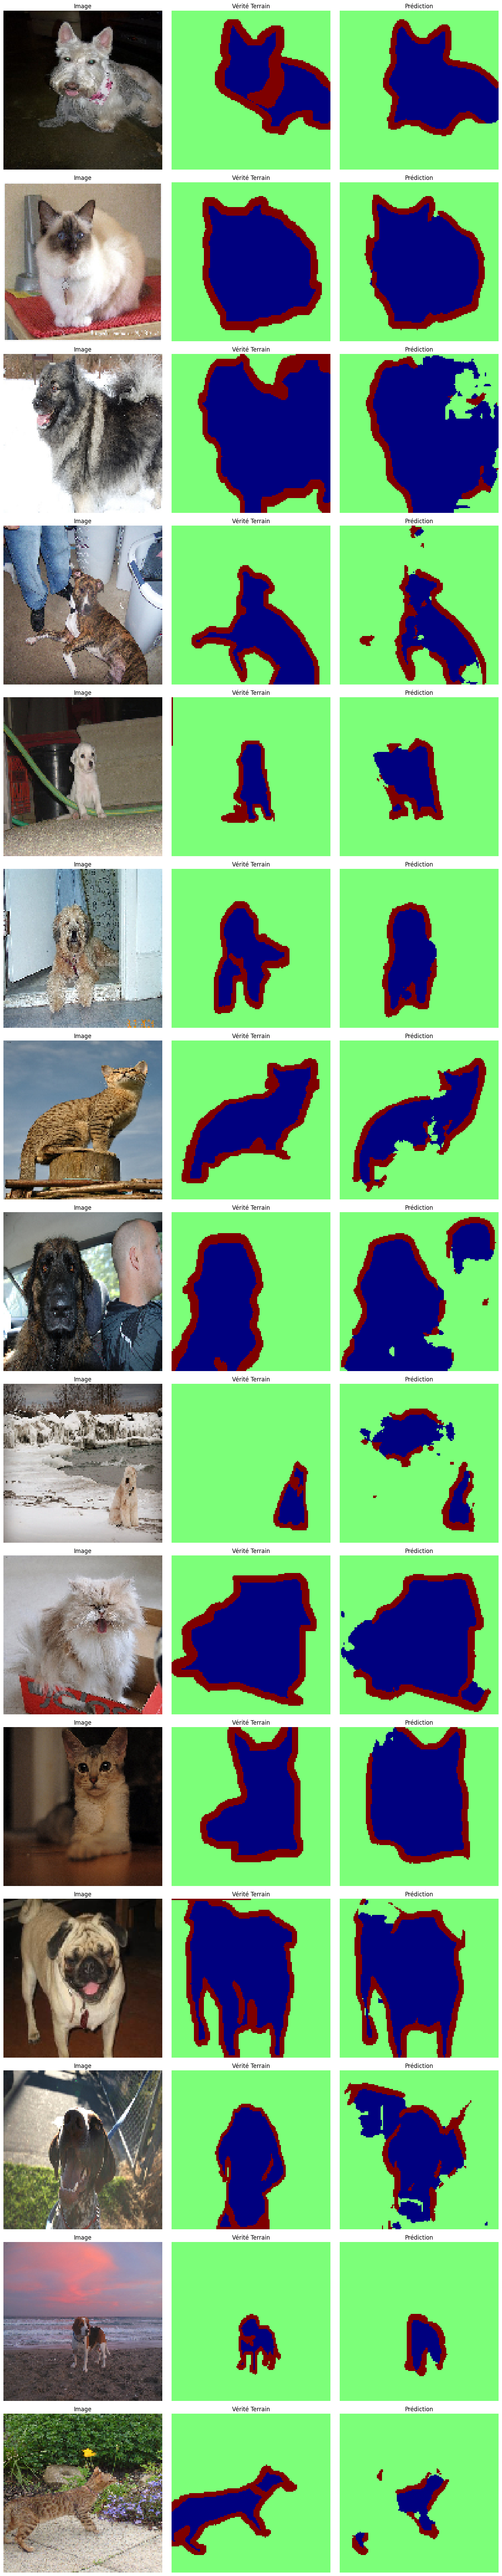

In [61]:
display_prediction(model, X_test, y_test, 15)

#### C. Comparaison des performances entre les races

Analyse de toutes les races (Chiens & Chats) sur 1470 images...
Calcul des scores IoU par image...

CLASSEMENT PAR RACE (Par performance IoU)
          Race Espèce  Mean_IoU  Count
  newfoundland    Dog  0.728068     44
great_pyrenees    Dog  0.718878     33
           pug    Dog  0.716260     34
       samoyed    Dog  0.714308     36
     shiba_inu    Dog  0.704086     46

... (milieu du classement) ...

              Race Espèce  Mean_IoU  Count
miniature_pinscher    Dog  0.621358     36
            beagle    Dog  0.618371     33
        Abyssinian    Cat  0.604966     40
             boxer    Dog  0.595799     39
        pomeranian    Dog  0.594530     31


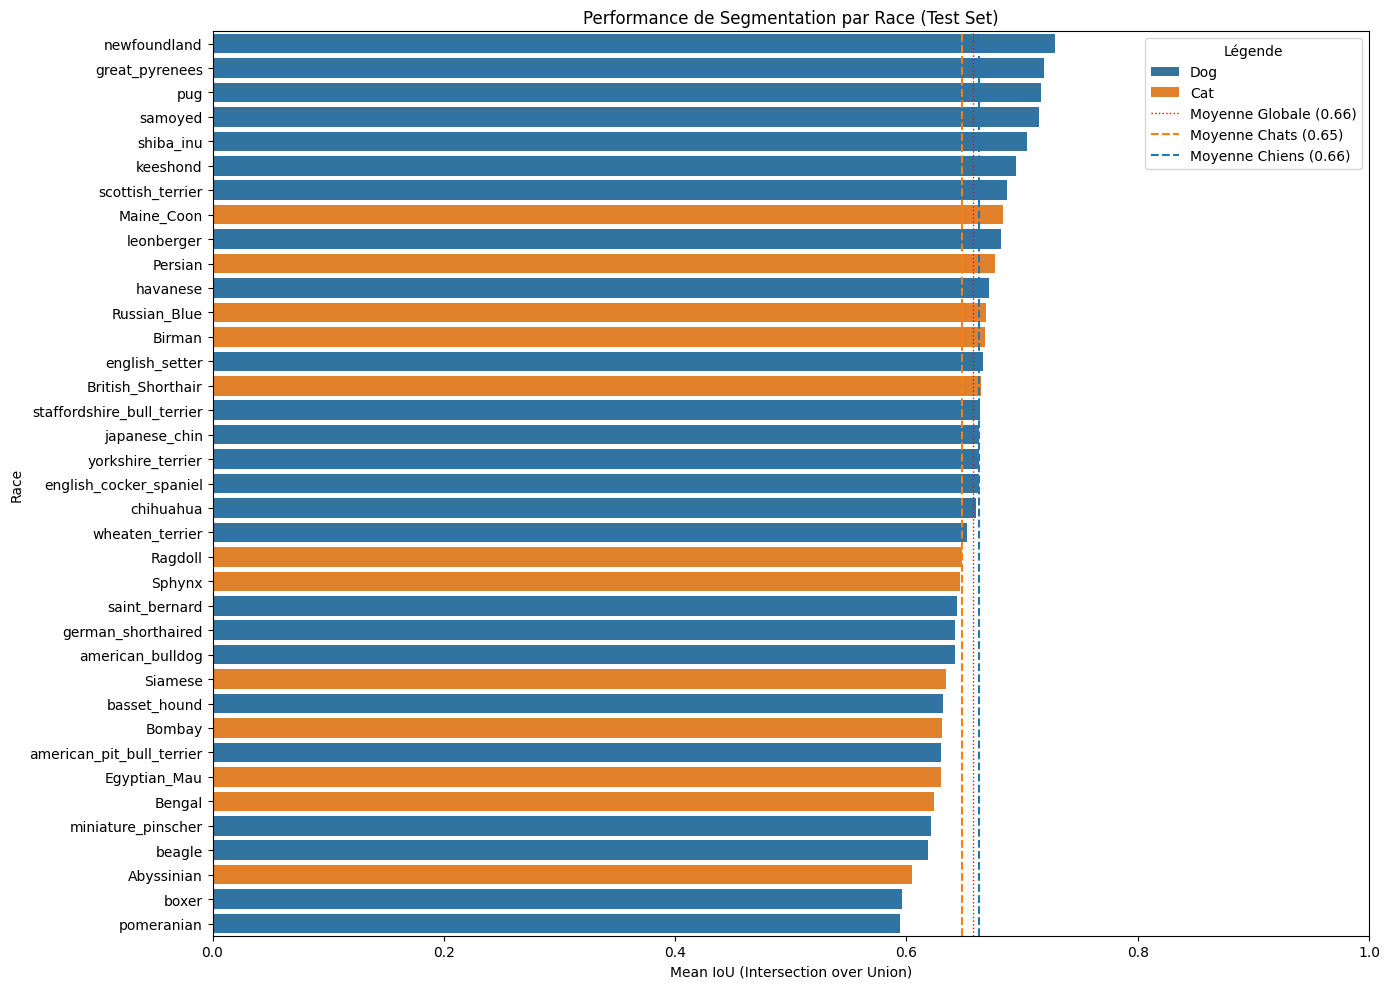

In [62]:
def calculate_iou_single_image(y_true, y_pred, num_classes=3):
    """
    Calcule le Mean IoU pour une seule image (moyenne des IoU par classe).
    Gère le cas où une classe est absente de l'image (retourne NaN pour cette classe).
    """
    ious = []
    for c in range(num_classes):
        # Masques booléens pour la classe c
        tp_mask = (y_pred == c)
        tt_mask = (y_true == c)
        
        intersection = np.logical_and(tp_mask, tt_mask).sum()
        union = np.logical_or(tp_mask, tt_mask).sum()
        
        # Si la classe n'est présente ni dans la vérité terrain ni dans la prédiction,
        # on l'ignore (np.nan) pour ne pas fausser la moyenne.
        if union == 0:
            ious.append(np.nan) 
        else:
            ious.append(intersection / union)
            
    # Retourne la moyenne des IoU des classes présentes (ignorer les NaNs)
    return np.nanmean(ious)

# --- Fonction principale d'analyse ---
def compare_breeds_performance(model, x_data, y_data, df_metadata):
    print(f"Analyse de toutes les races (Chiens & Chats) sur {len(x_data)} images...")
    
    # 1. Prédictions sur tout le dataset
    preds = model.predict(x_data, verbose=0)
    preds_argmax = np.argmax(preds, axis=-1)
    
    # 2. Préparation Vérité Terrain (Conversion en masque 2D si nécessaire)
    if y_data.ndim == 4 and y_data.shape[-1] > 1:
        y_true_mask = np.argmax(y_data, axis=-1)
    else:
        y_true_mask = y_data.squeeze()

    # 3. Alignement des métadonnées
    df_aligned = df_metadata.reset_index(drop=True)
    
    # Dictionnaire pour stocker les résultats intermédiaires
    # Structure : {'NomRace': {'scores': [0.8, 0.9...], 'species': 'Cat'}, ...}
    breed_data = {}
    
    # 4. Boucle d'analyse image par image
    print("Calcul des scores IoU par image...")
    for i in range(len(x_data)):
        # Récupération des infos de l'image courante
        breed = df_aligned.loc[i, 'BREED_NAME']
        species = df_aligned.loc[i, 'SPECIES_NAME'] 
        
        # Calcul IoU pour cette image
        iou = calculate_iou_single_image(y_true_mask[i], preds_argmax[i])
        
        # Stockage du score
        if breed not in breed_data:
            breed_data[breed] = {'scores': [], 'species': species}
        breed_data[breed]['scores'].append(iou)
    
    # 5. Agrégation des résultats par race
    results = []
    for breed, data in breed_data.items():
        scores = np.array(data['scores'])
        # On retire les potentiels NaNs si une image entière était problématique (rare)
        scores = scores[~np.isnan(scores)]
        
        if len(scores) > 0:
            results.append({
                'Race': breed,
                'Espèce': data['species'], 
                'Mean_IoU': np.mean(scores),
                'Std_Dev': np.std(scores),
                'Count': len(scores)
            })
    
    # Création du DataFrame final trié
    results_df = pd.DataFrame(results).sort_values(by='Mean_IoU', ascending=False)
    
    # 6. Affichage Tableau Console
    print("\n" + "="*60)
    print("CLASSEMENT PAR RACE (Par performance IoU)")
    print("="*60)
    print(results_df[['Race', 'Espèce', 'Mean_IoU', 'Count']].head(5).to_string(index=False))
    print("\n... (milieu du classement) ...\n")
    print(results_df[['Race', 'Espèce', 'Mean_IoU', 'Count']].tail(5).to_string(index=False))
    
    # --- CALCUL DES MOYENNES PAR ESPÈCE ---
    mean_iou_cat = results_df[results_df['Espèce'] == 'Cat']['Mean_IoU'].mean()
    mean_iou_dog = results_df[results_df['Espèce'] == 'Dog']['Mean_IoU'].mean()
    mean_iou_global = results_df['Mean_IoU'].mean()

    # 7. Visualisation Graphique
    plt.figure(figsize=(14, max(10, len(results_df) * 0.25)))
    

    colors = {'Dog': '#1f77b4', 'Cat': '#ff7f0e'} 
    sns.barplot(
        data=results_df, 
        x='Mean_IoU', 
        y='Race', 
        hue='Espèce', 
        dodge=False,
        palette=colors
    )
    
    # --- Ajout des lignes pointillées ---
    # Ligne moyenne globale (en gris)
    plt.axvline(mean_iou_global, color='red', linestyle=':', linewidth=1, label=f'Moyenne Globale ({mean_iou_global:.2f})')

    # Ligne moyenne CHATS (Orange)
    plt.axvline(mean_iou_cat, color=colors['Cat'], linestyle='--', linewidth=1.5, label=f'Moyenne Chats ({mean_iou_cat:.2f})')

    # Ligne moyenne CHIENS (Bleu)
    plt.axvline(mean_iou_dog, color=colors['Dog'], linestyle='--', linewidth=1.5, label=f'Moyenne Chiens ({mean_iou_dog:.2f})')
    
    plt.title(f"Performance de Segmentation par Race (Test Set)")
    plt.xlabel("Mean IoU (Intersection over Union)")
    plt.xlim(0, 1.0) # IoU est toujours entre 0 et 1
    
    # Affichage de la légende 
    plt.legend(title='Légende')
    
    plt.tight_layout()
    plt.show()


compare_breeds_performance(model, X_test, y_test, test_df)

Les résultats mettent en évidence une disparité significative de performance, avec un écart de plus de 0.15 point d'IoU entre le haut et le bas du classement. Le Terre-Neuve (Newfoundland) domine l'analyse avec un score de 0.73, suivi de près par le Montagne des Pyrénées. Cette réussite s'explique principalement par la grande taille de ces animaux, qui minimise mathématiquement l'impact des erreurs de bordure sur le calcul de l'IoU. De plus, leurs robes souvent monochromes offrent un contraste fort et uniforme avec l'arrière-plan, facilitant la distinction fond/forme. À l'inverse, le Spitz nain (Pomeranian) enregistre la pire performance du jeu de test avec un score de 0.58. Ce résultat illustre la difficulté du modèle à traiter les sujets de petite taille dotés d'un pelage vaporeux, dont les contours flous complexifient la segmentation précise. Les races présentant des motifs tachetés, comme le Beagle ou le Boxer, se retrouvent également en difficulté, probablement à cause d'une fragmentation de la détection. L'Abyssinian, classé parmi les derniers, indique que le modèle peine davantage sur certaines morphologies félines ou des poses plus compactes. Il apparaît donc que la texture du pelage et la complexité des motifs visuels sont des facteurs déterminants dans la qualité de la prédiction. En conclusion, le modèle favorise nettement les sujets massifs aux silhouettes bien définies au détriment des animaux petits ou à poils longs.